# Looped Transformer

## 理论

Looped Transformer 所有层共享相同的权重 $\theta$，每层的输入是前一层输出与初始输入的和：

$$
\begin{aligned}
h_0 &= \text{input} \\
h_l &= \text{TransformerBlock}(h_{l-1} + h_0| \theta) \quad \text{for } l=1,2,...,L
\end{aligned}
$$

### 截断损失函数

$$\text{Loss}(\theta)=\mathbb{E}_P \left[ \frac{1}{b - b_0} \sum_{t = b_0}^{b} \frac{1}{k + 1} \sum_{i = 0}^{k} (Y_t(P^i | \theta) - f(x_{i+1}))^2 \right]$$
其中
- $\min_{\theta}$：这是我们在寻找一组最优的物理定律（模型参数 $\theta$）。
- $\mathbb{E}_P$：对所有生成的 Prompt 分布求期望。在统计物理中，这相当于求“系综平均”，即我们在无数种不同的初始条件（数据集）下测试这个定律是否普适。  
- $\frac{1}{b-b_0} \sum_{t=b_0}^{b}$：这是时间平均。$b$ 是总迭代次数，$T$ 是窗口大小，$b_0 = \max(b-T, 0)$。我们只关心系统演化到“稳态”附近的这段时间内(也就是$b_0$ 到 $b$ 的表现)，前面瞬态的误差我们不计较。  
- $\frac{1}{k+1} \sum_{i=0}^{k}$：这是空间/序列平均。也就是在给定不同长度的上下文 $P^i$ 时，模型预测下一个点的值与真实函数 $f(x_{i+1})$ 之间的均方误差。  
- $Y_t(P^i|\theta)$：在时间 $t$、给定历史信息 $P^i$ 和系统参数 $\theta$ 时，系统当前的状态输出。 

### 下游任务

- 数据生成方式：这篇论文解决的是纯粹的数学数据拟合问题。数据集是在训练循环中即时生成的浮点数向量。  
- 以最基础的 **线性回归（Linear Regression）** 为例：
  - 维度设定：问题维度 $d=20$，上下文样本数 $k=40$。  
  - 生成逻辑：每次迭代前，随机采样一个真实的参数 $w \sim \mathcal{N}(0, I_d)$。  
  - 采样输入：生成 $k+1$ 个输入样本（包含测试样本） $x_i \sim \mathcal{N}(0, I_d)$。  
  - 计算标签：$y_i = w^T x_i$。  
  - 拼接成 Prompt：最终喂给模型的序列 $P$ 是一个交替的序列 $(x_1, y_1, x_2, y_2, \dots, x_k, y_k, x_{test}, y_{dummy})$。
- 线性回归可以进一步改成非线性回归（比如 ReLU与Linear 叠加），或者更复杂的物理系统。

#### 把 Prompt 映射到高维 Embedding 空间

**双通道映射与“拉链式”交织**

由于 `x` 和 `y` 代表不同的物理量（一个是空间坐标/特征，一个是目标观测值），我们需要赋予它们独立的投影空间：

1.	定义两个独立的线性层：
```python
read_in_x = nn.Linear(20, 256)
read_in_y = nn.Linear(1, 256)
```
2.	把前`k`个 `x_i` 丢给 `read_in_x`，变成张量 `X_emb`，形状为 `[batch, k, 256]`。
3.	把前`k`个 `y_i` 丢给 `read_in_y`，变成张量 `Y_emb`，形状为 `[batch, k, 256]`。
4.	像拉拉链一样，在`seq_len`维度上把`X_emb`、`Y_emb`交织（Interleave）起来，拼接成最终长度为 `2k` 的提示向量 `P`。

在工程实现中，我们在 $x_{test}$ 后填充了一个 $y_{dummy}$（如 0），使实际拼接长度变为 `2k+2`（偶数）。因此，真正对 $x_{test}$ 的预测结果位于输出序列的倒数第二个位置，即索引 `[-2]` 处。

## 架构各模块代码

### import

In [178]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
from operator import sub
import copy
import numpy as np
import math
import concurrent.futures
import threading
import os

### 位置编码(PE, Position Encoding)

#### 绝对位置编码(APE, Absolute Position Encoding)

In [179]:
class APE(nn.Module):
    def __init__(self, d_model, max_seq_len=4096, b=10000):
        super().__init__()
        theta_i = 1 / (b ** (torch.arange(0, d_model, 2).float() / d_model)) # [d_model/2]
        m = torch.arange(max_seq_len).float() # [max_seq_len]
        m_theta_i = torch.outer(m, theta_i) # [max_seq_len, d_model/2]
        # APE 核心：直接生成一个完整的 pe 矩阵，偶数维度放 sin，奇数维度放 cos
        stacked=torch.stack((torch.sin(m_theta_i), torch.cos(m_theta_i)), dim=-1) # [max_seq_len, d_model/2, 2]
        pe=stacked.flatten(1,2) # [max_seq_len, d_model]
        self.register_buffer('pe', pe.unsqueeze(0)) # shape: [1, max_seq_len, d_model]

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.shape[1], :]

#### Learned APE

In [180]:
class LearnedAPE(nn.Module):
    def __init__(self, d_model, max_seq_len=4096):
        super().__init__()
        self.pe = nn.Embedding(max_seq_len, d_model) 

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        seq_len = x.shape[1]
        positions = torch.arange(seq_len, device=x.device)
        return x + self.pe(positions).unsqueeze(0)

#### ALiBi (Attention with Linear Biases)

ALiBi 通过更改内积的方式引入线性位置偏置，从而实现了位置编码的功能。
$$ \text{Score}(q_i, k_j) = q_i \cdot k_j - m \cdot (i-j) \quad (i \ge j)$$
其中$m$是一个与头数($H$)相关的斜率参数，硬编码为
$$ m_h = 2^{-\frac{8h}{H}} \quad h=0,1,...,H-1$$

In [181]:
class ALiBi(nn.Module):
    def __init__(self, num_heads, max_seq_len=4096):
        super().__init__()
        dist = torch.arange(max_seq_len) # [max_seq_len]
        dist_matrix = torch.abs(dist.view(-1, 1) - dist.view(1, -1))  # [max_seq_len, max_seq_len]
        bias = -(2**-(8*torch.arange(1,num_heads+1) / num_heads)).view(-1, 1, 1) * dist_matrix.unsqueeze(0)  # [num_heads, max_seq_len, max_seq_len]
        # 因果掩码
        tril = torch.tril(torch.ones(max_seq_len, max_seq_len)).bool() # torch.tril (triangular lower)提取下三角元素，并把上三角元素置0
        mask = torch.zeros(max_seq_len, max_seq_len).masked_fill(~tril, float('-inf')) # 下三角元素置0，上三角元素置-inf
        self.register_buffer('fused_mask', bias + mask) # [num_heads, max_seq_len, max_seq_len]
    
    def forward(self, seq_len):
        # score shape: [batch_size, num_heads, seq_len, seq_len]
        return self.fused_mask[:, :seq_len, :seq_len]

#### 原来的 RoPE (Rotary Position Encoding)

In [182]:
class RoPE(nn.Module):
    def __init__(self, d_k, max_seq_len = 4096, b=10000):
        super().__init__()
        theta_i = 1/(b**(torch.arange(0,d_k,2).float()/d_k))  # \theta_i = b^{-\frac{2i}{d}}, \quad i \in \{0,1,\dots,\frac{d}{2}-1\}
        m = torch.arange(max_seq_len).float()  # m = [0,1,...,seq_len-1]
        m_theta_i = torch.outer(m, theta_i)  # [seq_len, d_k/2]
        cos = torch.cos(torch.cat((m_theta_i, m_theta_i), dim=-1))  # [seq_len, d_k]
        sin = torch.sin(torch.cat((m_theta_i, m_theta_i), dim=-1))  # [seq_len, d_k]
        self.register_buffer('cos', cos[None, None, :, :])  # 好处：cos和sin不需要更新参数，注册为buffer后会自动放到正确的设备上
        self.register_buffer('sin', sin[None, None, :, :])  # 扩充维度以适应后续计算

    def forward(self, x): # 适用于Q、K (V不需要位置编码!)
        # x: [batch_size, num_heads, seq_len, d_k]
        seq_len = x.shape[2]
        d_2 = x.shape[-1] // 2
        cos = self.cos[:, :, :seq_len, :]  # [1, 1, seq_len, d_k]
        sin = self.sin[:, :, :seq_len, :]
        x_first_half = x[..., :d_2]
        x_second_half = x[..., d_2:]
        x_flip = torch.cat((-x_second_half, x_first_half), dim=-1)  
        x_out = x * cos + x_flip * sin  # 旋转位置编码
        return x_out

#### 自创：Multi-Scale Untied Positional Encoding (MS-UPE)

In [183]:
class MS_UPE(nn.Module):
    def __init__(self,num_heads, d_k, max_seq_len = 4096, b_0=10000, head_ratio=2):
        super().__init__()
        b=(b_0*(head_ratio**(torch.arange(0, num_heads)))).float() # [num_heads]
        # \theta_i = b^{-\frac{2i}{d}}, \quad i \in \{0,1,\dots,\frac{d}{2}-1\} 
        theta_i = 1/(b.unsqueeze(1)**(torch.arange(0,d_k,2).float()/d_k).unsqueeze(0))  # [num_heads, d_k/2]
        m = torch.arange(max_seq_len).float()  # m = [0,1,...,seq_len-1]
        m_theta_i = torch.einsum('m,hk->hmk', m, theta_i)  # [num_heads, seq_len, d_k/2]
        pe = torch.cat((torch.cos(m_theta_i), torch.sin(m_theta_i)), dim=-1)  # [num_heads, seq_len, d_k] 
        self.register_buffer('pe', pe[None, :, :, :])  # 好处：pe不需要更新参数，注册为buffer后会自动放到正确的设备上

    def forward(self, x): # 适用于Q、K (V不需要位置编码!)
        # x: [batch_size, num_heads, seq_len, d_k]
        seq_len = x.shape[2]
        pe = self.pe[:, :, :seq_len, :]  # [1, num_heads, seq_len, d_k] 
        x_out = x + pe
        return x_out

### Multi-Head Attention

注：`APE` 应该加在 `ToyModel` 上而不是 `TransformerBlock` 上，因为我们只需要最开头输入处编码位置，而不是叠加 `num_blocks` 次。

In [184]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, d_model, max_seq_len=4096, pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        # 维度属性
        self.num_heads = num_heads
        self.d_model = d_model
        self.d_k = d_model // num_heads
        # 权重矩阵
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False) 
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        # 位置编码模块
        self.pe_type = [pe_type] if isinstance(pe_type, str) else pe_type
        self.qk_pe_modules = nn.ModuleList()  
        self.sc_pe_modules = nn.ModuleList()
        for pe in self.pe_type:
            if pe == 'rope':
                pe_module = RoPE(d_k=self.d_k, max_seq_len=max_seq_len, b=b_rope_or_upe)
                self.qk_pe_modules.append(pe_module)  # RoPE应用于Q和K
            elif pe == 'ms_upe':
                pe_module = MS_UPE(num_heads=num_heads, d_k=self.d_k, max_seq_len=max_seq_len, b_0=b_rope_or_upe, head_ratio=head_ratio_upe)
                self.qk_pe_modules.append(pe_module)  # MS-UPE应用于Q和K
            elif pe == 'alibi':
                pe_module = ALiBi(num_heads=num_heads, max_seq_len=max_seq_len)
                self.sc_pe_modules.append(pe_module)  # ALiBi应用于score矩阵
            elif pe in ['ape', 'learned_ape']:
                pass  # APE和Learned APE在输入时直接加到x上，不需要单独模块
        # 因果掩码
        tril = torch.tril(torch.ones(max_seq_len, max_seq_len)).bool() # torch.tril (triangular lower)提取下三角元素，并把上三角元素置0
        mask = torch.zeros(max_seq_len, max_seq_len).masked_fill(~tril, float('-inf')) # 下三角元素置0，上三角元素置-inf
        self.register_buffer('mask', mask[None, None, :, :])  # [1, 1, seq_len, seq_len]

    def forward(self, x): # x: [batch_size, seq_len, d_model]
        # 线性投影与分头
        batch_size, seq_len, _ = x.shape
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # [batch_size, num_heads, seq_len, d_k]
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # 交换(1, 2)是因为之后softmax时要进行矩阵乘法(只乘后两维)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # 在seq_len维度上分配注意力
        # 根据选择的PE类型对Q和K进行位置编码
        for pe_module in self.qk_pe_modules:
            Q = pe_module(Q)
            K = pe_module(K)
        if not self.training:
            # 缩放点积注意力与因果掩码 Causal Masking
            ## Query-Key 点积计算注意力得分
            scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)  # [batch_size, num_heads, seq_len, seq_len]
            if self.sc_pe_modules:
                fused_mask = self.sc_pe_modules[0](seq_len)  # [num_heads, seq_len, seq_len]
                scores = scores + fused_mask  # 将ALiBi的偏置加到得分上
                attention = F.softmax(scores, dim=-1)  # [batch_size, num_heads, seq_len, seq_len]
            else:
                ## 因果掩码和 softmax 计算注意力权重
                attention = F.softmax(scores + self.mask[..., :seq_len, :seq_len], dim=-1)  # [batch_size, num_heads, seq_len, seq_len]
            self.captured_attention = attention  # **新增**：捕获注意力矩阵，用hook记录下来，方便后续分析
            ## 乘以 Value 完成加权求和
            out = torch.matmul(attention, V)  # [batch_size, num_heads, seq_len, d_k]
        else:
            self.captured_attention = None  # 训练模式下不捕获注意力矩阵，节省内存
            if self.sc_pe_modules:
                fused_mask = self.sc_pe_modules[0](seq_len)  # [num_heads, seq_len, seq_len]
                out = F.scaled_dot_product_attention(Q, K, V, attn_mask=fused_mask, is_causal=False)  # [batch_size, num_heads, seq_len, d_k]
            else:
                out = F.scaled_dot_product_attention(Q, K, V, is_causal=True)  # [batch_size, num_heads, seq_len, d_k]
        # 多头拼接并乘以输出矩阵(必须先内存连续化(contiguous)再view，否则会报错)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)  # [batch_size, seq_len, d_model]
        H = self.W_O(out)  # [batch_size, seq_len, d_model]
        return H

### SwiGLU 和 单个 Transformer Block 架构不变

In [185]:
class SwiGLU(nn.Module):
    def __init__(self,d_model,d_hidden):
        super().__init__()
        self.W = nn.Linear(d_model,d_hidden,bias=False)
        self.V = nn.Linear(d_model,d_hidden,bias=False)
        self.W2 = nn.Linear(d_hidden,d_model,bias=False)
    def forward(self,x):
        x1 = F.silu(self.W(x))
        x2 = self.V(x)
        x_out = self.W2(x1 * x2)
        return x_out

In [186]:
class TransformerBlock(nn.Module):
    def __init__(self, num_heads, d_model, max_seq_len=4096, multiplier=4, norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2):
        super().__init__()
        if norm_type == 'rmsnorm':
            self.norm1 = nn.RMSNorm(d_model)  # 第一次归一化
            self.norm2 = nn.RMSNorm(d_model)  # 第二次归一化
        elif norm_type == 'layernorm':
            self.norm1 = nn.LayerNorm(d_model)  # 第一次归一化
            self.norm2 = nn.LayerNorm(d_model)  # 第二次归一化
        self.attention = MultiHeadAttention(num_heads=num_heads, d_model=d_model, max_seq_len=max_seq_len, pe_type=pe_type, b_rope_or_upe=b_rope_or_upe, head_ratio_upe=head_ratio_upe)
        if ffn_type == 'swiglu':
            self.ffn = SwiGLU(d_model=d_model, d_hidden=d_model * multiplier)
        elif ffn_type == 'gelu':
            self.ffn = nn.Sequential(
                nn.Linear(d_model, d_model * multiplier),
                nn.GELU(),
                nn.Linear(d_model * multiplier, d_model)
            )
    
    def forward(self, x):
        # 第一次归一化 Pre-Norm
        x_norm1 = self.norm1(x)
        # 全局信息交互 Multi-Head Attention (MHA)
        h = self.attention(x_norm1)
        # 第一次残差连接
        x1 = x + h
        # 第二次归一化
        x_norm2 = self.norm2(x1)
        # 前馈网络 Feed-Forward Network (FFN) 
        x_out = self.ffn(x_norm2)
        # 第二次残差连接
        x2 = x1 + x_out
        return x2

### Attention Probe

#### 返回全量 attention 的probe

In [187]:
class AttentionProbe:
    def __init__(self):
        self.captured_data = []
    def __call__(self, module, input, output):
        if getattr(module, 'captured_attention', None) is not None:
            attention = module.captured_attention.detach().cpu().numpy() 
            self.captured_data.append(attention)
        else:
            self.captured_data.append(None)  # 如果没有捕获到注意力矩阵，记录一个None占位符
    def reset(self):
        self.captured_data = [] 

#### 计算 sink score 和 sink rate 的 probe

针对层 $l$ 的第 $k$ 个 token 位置，sink rate 的计算公式定义如下：  
- Sink Score (汇聚得分)：$$\text{sink score}_{k}^{(l,h)} = \frac{1}{T}\sum_{t=0}^{T-1}\alpha_{tk}^{(l,h)}$$ 
- Sink Rate (汇聚率)：$$\text{sink rate}_{k}^{(l)} = \frac{1}{H}\sum_{h=1}^{H}\mathbb{I}(\text{sink score}_{k}^{(l,h)} \ge \tau)$$  

公式参数说明：
- $\alpha_{tk}^{(l,h)}$ 表示在层 $l$ 的第 $h$ 个注意力头中，从 token $t$ 到 token $k$ 的注意力权重。  
- $T$ 是序列的总长度。  
- $H$ 是每层注意力头的总数量。  
- $\mathbb{I}$ 是指示函数（当条件 $\text{sink score}_{k}^{(l,h)} \ge \tau$ 成立时取值为 1，否则为 0）。  
- 阈值 $\tau$ 通常被默认设置为 0.3。 

In [188]:
class SinkMetricsProbe:
    def __init__(self, threshold=0.3):
        self.threshold = threshold
        self.captured_scores = []
        self.captured_rates = []

    def __call__(self, module, input, output):
        if getattr(module, 'captured_attention', None) is not None:
            with torch.no_grad(): # attention矩阵仍在GPU上
                attention = module.captured_attention # [batch_size, num_heads, seq_len, seq_len]
                sink_attention = attention[:, :, :, 0]  # [batch_size, num_heads, seq_len]
                score_head = sink_attention.mean(dim=2).mean(dim=0)  # [num_heads]
                score = score_head.mean().item()  # 平均所有头的 sink score
                rate = (score_head >= self.threshold).float().mean().item()  # 大于等于 threshold 的头占总头数的比例
                self.captured_scores.append(score)
                self.captured_rates.append(rate)
        else:
            self.captured_scores.append(None)  # 如果没有捕获到注意力矩阵，记录一个None占位符
            self.captured_rates.append(None)

    def reset(self):
        self.captured_scores = []
        self.captured_rates = []

### Toy Model: Looped Transformer

In [189]:
class ToyModel(nn.Module):
    def __init__(self, num_blocks, num_heads, d_model, max_seq_len=4096, x_init='prompt',
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2, sink_threshold=0.3,
                 loop=True, residual_gate=(1,1), residual_gate_type='fixed', residual_random=(1,0.1)):
        super().__init__()
        self.loop = loop
        self.x_init = x_init
        if residual_gate==(0,0):
            raise ValueError("residual_gate cannot be (0,0) because then the model would be unable to learn anything (the input would be completely blocked)")
        if residual_gate[1] ==0 and x_init=='zero':
            self.x_init = 'prompt'  
            print("Warning: x_init is set to 'prompt' because residual_gate[1] is 0, which would make the model completely blind.")

        if loop:
            self.transformer_block = TransformerBlock(num_heads=num_heads, d_model=d_model, max_seq_len=max_seq_len, norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, b_rope_or_upe=b_rope_or_upe, head_ratio_upe=head_ratio_upe) # 这里保证了各层权重始终相同
            self.probe = AttentionProbe()
            self.sink_metrics_probe = SinkMetricsProbe(threshold=sink_threshold)
            self.transformer_block.attention.register_forward_hook(self.probe)
            self.transformer_block.attention.register_forward_hook(self.sink_metrics_probe)
            self.captured_attention = None
            self.captured_sink_scores = None
            self.captured_sink_rates = None
        else:
            self.transformer_block = nn.ModuleList([
                TransformerBlock(num_heads=num_heads, d_model=d_model, max_seq_len=max_seq_len, norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, b_rope_or_upe=b_rope_or_upe, head_ratio_upe=head_ratio_upe) 
                for _ in range(num_blocks)
            ])
            self.probe = [AttentionProbe() for _ in range(num_blocks)]
            self.sink_metrics_probe = [SinkMetricsProbe(threshold=sink_threshold) for _ in range(num_blocks)]
            for block, probe, sink_probe in zip(self.transformer_block, self.probe, self.sink_metrics_probe):
                block.attention.register_forward_hook(probe)
                block.attention.register_forward_hook(sink_probe)

        residual_random = torch.tensor(residual_random, dtype=torch.float32)
        if residual_gate == 'random':
            residual_gate_tensor = torch.randn(2)*residual_random[1]+residual_random[0] # 随机初始化门控参数，初始正态分布
        else:
            residual_gate_tensor = torch.tensor(residual_gate, dtype=torch.float32)  # 将输入的元组转换为张量，方便后续计算
        if residual_gate_type == 'fixed':
            self.register_buffer('residual_gate', residual_gate_tensor)  # 固定的门控参数，注册为buffer使其成为模型状态的一部分，但不参与梯度更新
        elif residual_gate_type == 'learnable_scalar':
            self.residual_gate = nn.Parameter(torch.ones(2)*residual_gate_tensor)  # 可学习的标量门控参数，初始值为用户指定的值
        elif residual_gate_type == 'learnable_vector':
            if residual_gate == 'random':
                self.residual_gate = nn.Parameter(torch.randn(d_model, 2)*residual_random[1]+residual_random[0]) # 可学习的向量门控参数，初始值为随机向量
            else:
                self.residual_gate = nn.Parameter(torch.ones(d_model, 2)*residual_gate_tensor)  # 可学习的向量门控参数，初始值为全1向量
            
        pe_type = self.transformer_block.attention.pe_type
        self.ape = nn.ModuleList()
        for pe in pe_type:
            if pe == 'ape':
                self.ape.append(APE(d_model, max_seq_len=max_seq_len))
            elif pe == 'learned_ape':
                self.ape.append(LearnedAPE(d_model, max_seq_len=max_seq_len))
            elif pe in ['rope', 'ms_upe']:
                pass # RoPE和MS_UPE在MultiHeadAttention内部处理位置编码，不需要单独的模块在这里处理

        self.num_blocks = num_blocks
        self.num_heads = num_heads
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        self.pe_type = pe_type

    def forward(self, x_0, num_eff=15, current_blocks=None): 
        # num_eff 是需要加入误差计算的有效层数，也即理论公式中的 T
        # x 的形状为 [batch_size, seq_len, d_model]
        a=self.residual_gate[...,0]
        b=self.residual_gate[...,1]
        for ape_module in self.ape:
            x_0 = ape_module(x_0) # 绝对位置编码只加在最开始输入处
        if self.x_init == 'prompt':
            x = x_0
        elif self.x_init == 'zero':
            x = torch.zeros_like(x_0) # 直接用全零向量作为初始输入，测试模型是否能从零开始学习
        else:
            raise ValueError(f"Invalid x_init value: {self.x_init}. Expected 'prompt' or 'zero'.")
        if current_blocks is None:
            current_blocks = self.num_blocks
        b_0 = max(0, current_blocks - num_eff) # 计算需要加入误差计算的有效层数对应的起始层索引
        outputs = []
        if self.loop:
            self.probe.reset() # 每次前向传播前重置捕获的数据，避免混淆不同次前向传播的注意力矩阵
            self.sink_metrics_probe.reset() # 同样重置 sink metrics 的捕获数据
            for i in range(current_blocks):
                if i == b_0:
                    x= x.detach() # 释放前面的计算图
                    x.requires_grad_(True)
                x = self.transformer_block(a*x+b*x_0)
                if i >= b_0: 
                    outputs.append(x) 
            self.captured_attention = list(self.probe.captured_data) # 显式copy一份数据，避免后续被修改
            self.captured_sink_scores = list(self.sink_metrics_probe.captured_scores)
            self.captured_sink_rates = list(self.sink_metrics_probe.captured_rates)
        else:
            for probe in self.probe:
                probe.reset()
            for sink_probe in self.sink_metrics_probe:
                sink_probe.reset()
            for i, block in enumerate(self.transformer_block[:current_blocks]): # 只迭代当前有效层数，避免不必要的计算
                if i == b_0:
                    x= x.detach() # 释放前面的计算图
                    x.requires_grad_(True)
                x = block(a*x+b*x_0) # x: [batch_size, seq_len, d_model]
                if i >= b_0: 
                    outputs.append(x)
            self.captured_attention = [probe.captured_data[-1] if probe.captured_data else None for probe in self.probe]
            self.captured_sink_scores = [sink_probe.captured_scores[-1] if sink_probe.captured_scores else None for sink_probe in self.sink_metrics_probe]
            self.captured_sink_rates = [sink_probe.captured_rates[-1] if sink_probe.captured_rates else None for sink_probe in self.sink_metrics_probe]
        outputs = torch.stack(outputs, dim=1) # [batch_size, num_eff, seq_len, d_model]
        return outputs

### Task: Regression

#### 转换头

In [190]:
class RegressionHead(nn.Module):
    def __init__(self, d_model, d_x, d_y=1, bias=False, init_scale=None):
        super().__init__()
        self.read_in_x = nn.Linear(d_x, d_model, bias=bias)
        self.read_in_y = nn.Linear(d_y, d_model, bias=bias)
        if init_scale is not None:
            nn.init.normal_(self.read_in_x.weight, mean=0.0, std=init_scale)
            nn.init.normal_(self.read_in_y.weight, mean=0.0, std=init_scale)
    def forward(self, x_data, y_data):
        # k相当于seq_len的一半，因为x和y交织在一起，所以总的seq_len是2k
        # x_data: [batch_size, k, d_x]
        # y_data: [batch_size, k, d_y]
        x_emb = self.read_in_x(x_data)  # [batch_size, k, d_model]
        y_emb = self.read_in_y(y_data)  # [batch_size, k, d_model]
        # 交织成 (x_1, y_1, x_2, y_2, ..., x_k, y_k)
        stacked = torch.stack((x_emb, y_emb), dim=2)  # [batch_size, k, 2, d_model]
        Prompt = stacked.flatten(1,2)  # [batch_size, 2k, d_model]
        return Prompt

#### 损失函数

In [191]:
class PredictionLoss(nn.Module):
    def __init__(self, d_model, d_y=1, loss_type='mse', layer_weight_decay=1.0, seq_weight_decay=1.0, norm_type='rmsnorm'):
        super().__init__()
        if norm_type == 'rmsnorm':
            self.ln_f = nn.RMSNorm(d_model)
        elif norm_type == 'layernorm':
            self.ln_f = nn.LayerNorm(d_model)
        self.read_out = nn.Linear(d_model, d_y)
        self.layer_weight_decay = layer_weight_decay
        self.seq_weight_decay = seq_weight_decay
        if loss_type == 'mse':
            self.loss_fn = nn.MSELoss(reduction='none')
        elif loss_type == 'l1':
            self.loss_fn = nn.L1Loss(reduction='none')

    def forward(self, outputs, y_true, is_eval=False, sink_padding=None): 
        # outputs:[batch_size, num_eff, seq_len, d_model]
        # y_true: [batch_size, seq_len/2, 1]
        if is_eval:
            y_outputs = outputs[:, -1, -2, :] # 只取最后一层的最后一个位置的输出作为预测值
            y_outputs = self.ln_f(y_outputs)
            y_pred_final = self.read_out(y_outputs) # [batch_size, d_y]
            return y_pred_final
        y_outputs = outputs[:, :, 0::2, :] # [batch_size, num_eff, seq_len/2, d_model]
        y_outputs = self.ln_f(y_outputs)
        y_preds = self.read_out(y_outputs) # [batch_size, num_eff, seq_len/2, d_y]
        if sink_padding is not None:
            y_preds = y_preds[:, :, sink_padding:, :]
            y_true = y_true[:, sink_padding:, :]
        y_pred_norm = torch.sqrt(torch.mean(y_preds.detach() ** 2)).item()
        y_true_norm = torch.sqrt(torch.mean(y_true.detach() ** 2)).item()
        loss_unreduced = self.loss_fn(y_preds, y_true.unsqueeze(1).expand_as(y_preds)) # [batch_size, num_eff, seq_len/2, d_y]
        if self.layer_weight_decay != 1.0:
            num_eff = outputs.shape[1]
            layer_weights = self.layer_weight_decay ** torch.arange(num_eff-1, -1, -1, device=outputs.device)  # 从最后一层到第一层递减的权重
            layer_weights = layer_weights / layer_weights.mean()  
            loss_unreduced = loss_unreduced * layer_weights.view(1, num_eff, 1, 1)  # 按层加权
        if self.seq_weight_decay != 1.0:
            k=loss_unreduced.shape[2]
            seq_weights = self.seq_weight_decay ** torch.arange(k-1, -1, -1, device=outputs.device)  # 从最后一次预测到第一次预测递减的权重
            seq_weights = seq_weights / seq_weights.mean()  
            loss_unreduced = loss_unreduced * seq_weights.view(1, 1, k, 1)  # 按位置加权
        return loss_unreduced.mean(), y_pred_norm, y_true_norm

#### 拼装

In [192]:
class RegressionSolver(nn.Module):
    def __init__(self, num_blocks, num_heads, d_model, d_x, d_y, max_seq_len, 
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2,
                  loop=True, loss_type='mse', sink_threshold=0.3,
                  residual_gate=(1,1), residual_gate_type='fixed', residual_random=(1,0.1),
                  bias=False, init_scale=None, init_std=0.02, x_init='prompt',
                  layer_weight_decay=1.0, seq_weight_decay=1.0):
        super().__init__()
        if init_std == 'auto':
            init_std = d_model ** -0.5
        if init_std is not None:
            init_scale = None  # 如果用户指定了init_std，则忽略init_scale，使用init_std进行权重初始化
        self.toy_model = ToyModel(num_blocks=num_blocks, num_heads=num_heads, d_model=d_model, max_seq_len=max_seq_len, 
                                  norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, sink_threshold=sink_threshold,
                                  loop=loop, b_rope_or_upe=b_rope_or_upe, head_ratio_upe=head_ratio_upe, 
                                  residual_gate=residual_gate, residual_gate_type=residual_gate_type, residual_random=residual_random, x_init=x_init)
        self.head = RegressionHead(d_model=d_model, d_x=d_x, d_y=d_y, bias=bias, init_scale=init_scale)
        self.loss_fn = PredictionLoss(d_model=d_model, d_y=d_y, loss_type=loss_type, layer_weight_decay=layer_weight_decay, seq_weight_decay=seq_weight_decay, norm_type=norm_type)
        if init_std is not None:
            self.apply(lambda module: self._init_weights(module, init_std))
            std_res = init_std / math.sqrt(2 * num_blocks)
            # 遍历所有参数，通过名称匹配出残差输出层
            for name, param in self.named_parameters():
                # W_O 是 MultiHeadAttention 的输出
                # W2 是 SwiGLU 的输出
                # ffn.2 是普通 GELU 序列中的最后一个 Linear
                if name.endswith('W_O.weight') or name.endswith('W2.weight') or name.endswith('ffn.2.weight'):
                    torch.nn.init.normal_(param, mean=0.0, std=std_res)
    
    def _init_weights(self, module, init_std):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=init_std)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)
        
    def forward(self, x_data, y_data, num_eff, current_blocks=None, is_eval=False, sink_padding=None):
        Prompt = self.head(x_data, y_data) # [batch_size, seq_len, d_model]
        outputs = self.toy_model(Prompt, num_eff=num_eff, current_blocks=current_blocks) # [batch_size, num_eff, seq_len, d_model]
        return self.loss_fn(outputs, y_data, is_eval=is_eval, sink_padding=sink_padding)

### 数据生成与加载

#### 数据生成

##### 线性回归数据

In [193]:
def linear_data_generator(batch_size, seq_len, valid_d_x=None, d_x=20, d_y=1, device='cpu', generator=None, ood_kwargs=None):
    with torch.no_grad():
        if ood_kwargs is None:
            ood_kwargs = {}
        if valid_d_x is None:
            valid_d_x = d_x
        w = torch.randn(batch_size, d_x, d_y, device=device, generator=generator)/ (valid_d_x ** 0.5)  # 真实线性函数 w: [batch_size, d_x, d_y]
        if valid_d_x < d_x:
            w[:, valid_d_x:, :] = 0.0  # 将多余的输入维度对应的权重置零，保证它们对输出没有影响
        x_distribution = ood_kwargs.get('x_distribution', 'gaussian')
        if x_distribution == 'gaussian':
            x_data = torch.randn(batch_size, seq_len//2, d_x, device=device, generator=generator)  # 输入特征 x: [batch_size, seq_len//2, d_x]
        elif x_distribution == 'uniform':
            x_data = (torch.rand(batch_size, seq_len//2, d_x, device=device, generator=generator) * 2 - 1)/(3**0.5)  # 均匀分布,方差归一化为1
        elif x_distribution == 'laplace':
            x_data = torch.distributions.Laplace(0, 1/(2**0.5)).sample((batch_size, seq_len//2, d_x)).to(device)  # 拉普拉斯分布，方差归一化为1

        if 'x_scale' in ood_kwargs:
            x_data = x_data * ood_kwargs['x_scale']  # 调整输入特征的尺度，制造OOD数据
        if 'x_mean_shift' in ood_kwargs:
            x_data = x_data + ood_kwargs['x_mean_shift']  # 平移输入特征的均值，制造OOD数据
        if 'x_noise_std' in ood_kwargs:
            x_data = x_data + torch.randn_like(x_data) * ood_kwargs['x_noise_std']  # 添加输入特征的噪声，制造OOD数据

        if valid_d_x < d_x:
            x_data[..., valid_d_x:] = 0.0  # 将多余的输入维度对应的数据置零，保证它们对输出没有影响
            
        y_data = x_data @ w  # 计算标签 y = x @ w: [batch_size, seq_len//2, d_y]

        if 'y_scale' in ood_kwargs:
            y_data = y_data * ood_kwargs['y_scale']  # 调整标签的尺度，制造OOD数据
        if 'y_mean_shift' in ood_kwargs:
            y_data = y_data + ood_kwargs['y_mean_shift']  # 平移标签的均值，制造OOD数据
        if 'y_noise_std' in ood_kwargs:
            y_data = y_data + torch.randn_like(y_data) * ood_kwargs['y_noise_std']  # 添加标签的噪声，制造OOD数据

        return x_data, y_data

##### 非线性回归数据

In [194]:
def nonlinear_data_generator(batch_size, seq_len, valid_d_x=None, d_x=20, d_y=1, d_hidden=None, function_callable=None, device='cpu', generator=None, ood_kwargs=None):
    '''
    linear(d_x->d_hidden) + nonlinear_func + linear(d_hidden->d_y) 的形式生成数据
    function_callable: 非线性函数, 如 lambda x: F.relu(2*torch.sin(x))+torch.cos(x)
    d_hidden: 隐藏层维度，控制非线性函数的输入输出维度。
              若d_hidden=d_x，则第一层线性变换默认设定为恒等映射，数据生成过程变为nonlinear_func + linear的形式；
              若d_hidden=d_y，则第二层线性变换默认设定为恒等映射，数据生成过程变为linear + nonlinear_func的形式。
    '''
    with torch.no_grad():
        if ood_kwargs is None:
            ood_kwargs = {}
        if valid_d_x is None:
            valid_d_x = d_x

        w1 = torch.randn(batch_size, d_x, d_hidden, device=device, generator=generator)/ (valid_d_x ** 0.5)  # 第一层权重 w1: [batch_size, d_x, d_hidden]
        w2 = torch.randn(batch_size, d_hidden, d_y, device=device, generator=generator)/ (d_hidden ** 0.5)  # 第二层权重 w2: [batch_size, d_hidden, d_y]
        if valid_d_x < d_x:
            w1[:, valid_d_x:, :] = 0.0  # 将多余的输入维度对应的权重置零，保证它们对输出没有影响
        x_distribution = ood_kwargs.get('x_distribution', 'gaussian')
        if x_distribution == 'gaussian':
            x_data = torch.randn(batch_size, seq_len//2, d_x, device=device, generator=generator)  # 输入特征 x: [batch_size, seq_len//2, d_x]
        elif x_distribution == 'uniform':
            x_data = (torch.rand(batch_size, seq_len//2, d_x, device=device, generator=generator) * 2 - 1)/(3**0.5)  # 均匀分布,方差归一化为1
        elif x_distribution == 'laplace':
            x_data = torch.distributions.Laplace(0, 1/(2**0.5)).sample((batch_size, seq_len//2, d_x)).to(device)  # 拉普拉斯分布，方差归一化为1

        if 'x_scale' in ood_kwargs:
            x_data = x_data * ood_kwargs['x_scale']  # 调整输入特征的尺度，制造OOD数据
        if 'x_mean_shift' in ood_kwargs:
            x_data = x_data + ood_kwargs['x_mean_shift']  # 平移输入特征的均值，制造OOD数据
        if 'x_noise_std' in ood_kwargs:
            x_data = x_data + torch.randn_like(x_data) * ood_kwargs['x_noise_std']  # 添加输入特征的噪声，制造OOD数据

        if valid_d_x < d_x:
            x_data[..., valid_d_x:] = 0.0  # 将多余的输入维度对应的数据置零，保证它们对输出没有影响

        if d_x==d_hidden:
            w1=torch.eye(d_x, device=device).unsqueeze(0).expand(batch_size, -1, -1) # 如果输入维度和隐藏层维度相同，变为nonlinear_func + linear的形式
            if not getattr(nonlinear_data_generator, '_has_warned_w1_identity', False):
                print("Warning: w1 is set to identity matrix because d_x equals d_hidden.")
                nonlinear_data_generator._has_warned_w1_identity = True
        if d_hidden==d_y:
            w2=torch.eye(d_hidden, device=device).unsqueeze(0).expand(batch_size, -1, -1) # 如果隐藏层维度和输出维度相同，变为linear + nonlinear_func的形式
            if not getattr(nonlinear_data_generator, '_has_warned_w2_identity', False):
                print("Warning: w2 is set to identity matrix because d_hidden equals d_y.")
                nonlinear_data_generator._has_warned_w2_identity = True

        hidden = x_data @ w1  # [batch_size, seq_len//2, d_hidden]

        func=ood_kwargs.get('function_callable', function_callable) # Concept Shift
        # 应用非线性函数
        hidden = func(hidden)  # [batch_size, seq_len//2, d_hidden]
        # 第二层线性变换
        y_data = hidden @ w2  # [batch_size, seq_len//2, d_y]

        if 'y_scale' in ood_kwargs:
            y_data = y_data * ood_kwargs['y_scale']  # 调整标签的尺度，制造OOD数据
        if 'y_mean_shift' in ood_kwargs:
            y_data = y_data + ood_kwargs['y_mean_shift']  # 平移标签的均值，制造OOD数据
        if 'y_noise_std' in ood_kwargs:
            y_data = y_data + torch.randn_like(y_data) * ood_kwargs['y_noise_std']  # 添加标签的噪声，制造OOD数据
            
        return x_data, y_data

##### lorenz attractor 数据

**理论公式**

系统的演化由以下三个一阶非线性微分方程决定：
$$\begin{aligned}
\frac{dx}{dt} &= \sigma (y - x) \\
\frac{dy}{dt} &= x (\rho - z) - y \\
\frac{dz}{dt} &= xy - \beta z
\end{aligned}$$

**参数物理意义**
 * $x(t)$：表示流体运动的强度（对流速度）。
 * $y(t)$：表示上升和下降流体的温度差。
 * $z(t)$：表示垂直温度剖面的非线性畸变程度。
 * $\sigma$：Prandtl 数，影响流动特性
 * $\rho$：Rayleigh 数，决定对流强度
 * $\beta$：几何物理尺寸相关参数

**经典的混沌参数**
$\sigma = 10, \rho = 28, \beta = \frac{8}{3}$

此时，系统的轨迹会收敛到一个分形结构上，表现出极度敏感的混沌特性。任何微小的初始条件差异，都会导致后续轨迹的巨大分歧。

In [195]:
def lorenz_derivative(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    # state: [batch_size, 3]
    x, y, z = state[:, 0], state[:, 1], state[:, 2]
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return torch.stack((dx, dy, dz), dim=1)  # [batch_size, 3]

**四阶龙格-库塔法（简称 RK4）**

- 核心思想：**多看几步，求个平均**
  - k1：先看一眼当前位置的速度。
  - k2：试探性地往前走半步，看看那里的速度。
  - k3：根据上一步的结果，再在半步的位置看一眼速度。
  - k4：试探性地往前走一步，看看终点附近的速度。
- 最后，把这四个速度按照不同的权重（通常是两头轻、中间重）加权平均，作为最终的“靠谱速度”来更新位置。

In [196]:
def rk4_step(state, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0):
    k1 = lorenz_derivative(state, sigma, rho, beta)
    k2 = lorenz_derivative(state + 0.5 * dt * k1, sigma, rho, beta)
    k3 = lorenz_derivative(state + 0.5 * dt * k2, sigma, rho, beta)
    k4 = lorenz_derivative(state + dt * k3, sigma, rho, beta)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
try:
    rk4_step = torch.compile(rk4_step)
except Exception:
    pass

**lorenz数据计算**

In [197]:
def lorenz_kernel(init_state, total_steps:int, dt:float, sigma:float, rho:float, beta:float):
    # init_state: [batch_size, 3]
    batch_size = init_state.shape[0]
    device = init_state.device
    dtype = init_state.dtype
    trajectory = torch.empty((total_steps, batch_size, 3), device=device, dtype=dtype)
    current_state = init_state
    for t in range(total_steps):
        current_state = rk4_step(state=current_state, dt=dt, sigma=sigma, rho=rho, beta=beta)
        trajectory[t] = current_state
    trajectory = trajectory.transpose(0, 1)  # 转置为 [batch_size, total_steps, 3]
    return trajectory  # [batch_size, total_steps, 3]
'''try:
    lorenz_kernel = torch.compile(lorenz_kernel)
except Exception:
    pass'''

'try:\n    lorenz_kernel = torch.compile(lorenz_kernel)\nexcept Exception:\n    pass'

**把数据变成data_generator**

In [198]:
_lorenz_cache_lock = threading.Lock()  # 定义一个锁对象，确保线程安全
def lorenz_data_generator(batch_size, seq_len, valid_d_x=None, d_x=3, d_y=3, lorenz_kwargs=None, device='cpu', generator=None, ood_kwargs=None, load_path=None):
    with torch.no_grad():  # 数据生成过程中不需要计算梯度，使用no_grad加速
        if ood_kwargs is None:
            ood_kwargs = {}
        if valid_d_x is None:
            valid_d_x = d_x
        if lorenz_kwargs is None:
            lorenz_kwargs = {}
        burn_in = lorenz_kwargs.get('burn_in', 500) # 预热步数，默认为500步，确保系统状态进入混沌吸引子
        if load_path is not None and not os.path.exists(load_path):
            print(f"Warning: load_path {load_path} does not exist. Generating new Lorenz data.")
            load_path = None
        if load_path is not None:
            with _lorenz_cache_lock:
                if not hasattr(lorenz_data_generator, "_cache") or lorenz_data_generator._cache_path != load_path:
                    print(f"Loading Lorenz data from {load_path}...")
                    checkpoint = torch.load(load_path, map_location='cpu')
                    lorenz_data_generator._cache = checkpoint['trajectory']
                    lorenz_data_generator._cache_path = load_path
                    if ood_kwargs.get('init_distribution', 'gaussian') != 'gaussian' or ood_kwargs.get('lorenz_noise_std', 0.0) > 0.0 or ood_kwargs.get('sigma_shift', 0.0) != 0.0 or ood_kwargs.get('rho_shift', 0.0) != 0.0 or ood_kwargs.get('beta_shift', 0.0) != 0.0:
                        print("Warning: The loaded Lorenz data was generated with a Gaussian distribution , no noise and default parameters. If you want to generate OOD data with different distribution or noise, please set load_path to None.")
            pool = lorenz_data_generator._cache # [pool_size, traj_len, 3]
            pool_size = pool.shape[0]
            indices = torch.randint(0, pool_size, (batch_size,), device='cpu')
            batch_traj = pool[indices]  # [batch_size, traj_len, 3]
            if pool.shape[1] < burn_in + seq_len//2 + 1:
                old_burn_in = burn_in
                burn_in = max(0, pool.shape[1] - seq_len//2 - 1)
                print(f"Warning: The trajectories in the pool have length {pool.shape[1]}, which is less than burn_in + seq_len//2 + 1 = {old_burn_in + seq_len//2 + 1}. Burn-in will be automatically reduced to {burn_in}.")
            batch_traj = batch_traj[:, burn_in:burn_in+seq_len//2+1, :].to(device)  # [batch_size, seq_len//2+1, 3]
            x_data = batch_traj[:, :seq_len//2, :]  # [batch_size, seq_len//2, 3]
            y_data = batch_traj[:, 1:seq_len//2+1, :]  # [batch_size, seq_len//2, 3]
        
        else:
            dt = lorenz_kwargs.get('dt', 0.01) # 时间步长默认为0.01
            # 初始化
            total_steps = burn_in + seq_len//2 + 1
            init_distribution = ood_kwargs.get('init_distribution', 'gaussian')
            if init_distribution == 'gaussian':
                init_state = torch.randn(batch_size, 3, device=device, generator=generator) * 15 + torch.tensor([0, 0, 25.0], device=device)  # 初始状态（放大15倍并平移(0, 0, 25)以确保在洛伦兹吸引子中心附近）
            elif init_distribution == 'uniform':
                init_state = (torch.rand(batch_size, 3, device=device, generator=generator) * 30 - 15) + torch.tensor([0, 0, 25.0], device=device)  # 均匀分布，范围[-15, 15]，并平移(0, 0, 25)
            elif init_distribution == 'laplace':
                u = torch.rand(batch_size, 3, device=device, generator=generator) - 0.5
                init_state = torch.tensor([0, 0, 25.0], device=device) - (15 / (2**0.5)) * torch.sign(u) * torch.log(1 - 2 * torch.abs(u))
            noise_std = ood_kwargs.get('lorenz_noise_std', 0.0)
            sigma = ood_kwargs.get('sigma_shift', 0.0)+10.0
            rho = ood_kwargs.get('rho_shift', 0.0)+28.0
            beta = ood_kwargs.get('beta_shift', 0.0)+8.0/3.0
            # 生成轨迹
            trajectory = lorenz_kernel(init_state=init_state, total_steps=total_steps, dt=dt, sigma=sigma, rho=rho, beta=beta)[:, burn_in:, :]  # [batch_size, seq_len//2+1, 3]
            if noise_std > 0.0:
                trajectory = trajectory + torch.randn_like(trajectory) * noise_std  # 在观测轨迹上添加噪声，制造OOD数据
            x_data = trajectory[:, :-1, :]  # x_data: [batch_size, seq_len//2, 3]
            y_data = trajectory[:, 1:, :]   # y_data: [batch_size, seq_len//2, 3]
            
        # 裁剪或填充至给定维度
        if valid_d_x > 3:
            x_data = F.pad(x_data, (0, valid_d_x - 3), value=0.0)  # 将输入特征维度扩展到 valid_d_x，新增的维度填充为0
        elif valid_d_x < 3:
            x_data = x_data[:, :, :valid_d_x]  # 将输入特征维度裁剪到 valid_d_x
        if d_y > 3:
            y_data = F.pad(y_data, (0, d_y - 3), value=0.0)  # 将标签维度扩展到 d_y，新增的维度填充为0
        elif d_y < 3:
            y_data = y_data[:, :, :d_y]  # 将标签维度裁剪到 d_y
        return x_data, y_data

In [199]:
def clear_lorenz_cache():
    if hasattr(lorenz_data_generator, "_cache"):
        del lorenz_data_generator._cache
        del lorenz_data_generator._cache_path
        print("Lorenz data cache cleared.")
    else:
        print("No Lorenz data cache found.")

由于lorenz数据生成较慢，故预先生成离线数据池，训练时从中随机采样，评估时再在线生成。

In [200]:
def create_lorenz_pool(pool_size=10000, traj_len=500, dt=0.01, sigma=10.0, beta=8/3, rho=28.0, save_path='auto'):
    if save_path == 'auto':
        save_path = f'data/lorenz/length_{traj_len}_dt{dt}_sigma{sigma:.1f}_beta{beta:.1f}_rho{rho:.1f}.pth'
    with torch.no_grad():
        # 初始化
        if torch.cuda.is_available():
            device = 'cuda'
        elif torch.backends.mps.is_available():
            device = 'mps'
        else:        
            device = 'cpu'
        generator = torch.Generator(device=device)
        init_state = torch.randn(pool_size, 3, device=device, generator=generator) * 15 + torch.tensor([0, 0, 25], device=device)  # 初始状态（放大15倍并平移(0, 0, 25)以确保在洛伦兹吸引子中心附近）
        # 生成轨迹
        trajectory = lorenz_kernel(init_state=init_state, total_steps=traj_len, dt=dt, sigma=sigma, rho=rho, beta=beta)  # [pool_size, traj_len, 3]
        trajectory = trajectory.cpu()  # 将数据移回CPU，准备保存

        if save_path and os.path.exists(save_path):
            print(f"检测到已有数据文件，正在读取并进行增量拼接...")
            old_data = torch.load(save_path, map_location='cpu')
            old_trajectory = old_data['trajectory']
            if old_trajectory.shape[1] != trajectory.shape[1]:
                raise ValueError(f"拼接失败！本地老数据的时序长度为 {old_trajectory.shape[1]}，而你当前设定的时序长度要求为 {trajectory.shape[1]}。请保持参数一致！")
            # 在 Batch 维度 (dim=0) 进行无限追加拼接
            final_trajectory = torch.cat([old_trajectory, trajectory], dim=0)
            print(f"增量拼接成功！数据池规模由 {old_trajectory.shape[0]} 条扩大至 {final_trajectory.shape[0]} 条。")
        else:
            print(f"未检测到历史文件，正在创建全新的离线数据池...")
            final_trajectory = trajectory

        if save_path:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            torch.save({'trajectory': final_trajectory}, save_path)
            print(f"数据池已安全写入本地: {save_path}")

#### 数据加载器

In [201]:
def dataloader(batch_size=64, seq_len=80, valid_d_x=None, d_x=20, d_y=1, device='cpu', data_type='linear', d_hidden=None, function_callable=None, sink_padding=1, generator=None, ood_kwargs=None, lorenz_kwargs=None, load_lorenz_from=None):
    if valid_d_x is None:
        valid_d_x = d_x
    while True:
        if data_type == 'linear':
            x_data, y_data = linear_data_generator(batch_size=batch_size, seq_len=seq_len, valid_d_x=valid_d_x, d_x=d_x, d_y=d_y, device=device, generator=generator, ood_kwargs=ood_kwargs)
        elif data_type == 'nonlinear':
            x_data, y_data = nonlinear_data_generator(batch_size=batch_size, seq_len=seq_len, valid_d_x=valid_d_x, d_x=d_x, d_y=d_y, d_hidden=d_hidden, function_callable=function_callable, device=device, generator=generator, ood_kwargs=ood_kwargs)
        elif data_type == 'lorenz':
            x_data, y_data = lorenz_data_generator(batch_size=batch_size, seq_len=seq_len, valid_d_x=valid_d_x, d_x=d_x, d_y=d_y, device=device, generator=generator, ood_kwargs=ood_kwargs, lorenz_kwargs=lorenz_kwargs, load_path=load_lorenz_from)
        if sink_padding is not None:
            x_data = F.pad(x_data, (0, 0, sink_padding, 0), value=0)  # 在seq_len维度最前面添加sink_padding个全0向量
            y_data = F.pad(y_data, (0, 0, sink_padding, 0), value=0)
        yield x_data, y_data

### 显存检测

In [202]:
def print_vram_usage(tag="", peak=None):
    if torch.backends.mps.is_available():
        # MPS 专用 API (Apple Silicon)
        allocated = torch.mps.current_allocated_memory() / (1024 ** 3)
        driver_alloc = torch.mps.driver_allocated_memory() / (1024 ** 3)
        if peak is not None:
            print(f"[{tag}] 显存占用 -> PyTorch分配: {peak[0]:.2f} GB | Metal驱动分配: {peak[1]:.2f} GB")
        else:
            print(f"[{tag}] 显存占用 -> PyTorch分配: {allocated:.2f} GB | Metal驱动分配: {driver_alloc:.2f} GB")
        
    elif torch.cuda.is_available():
        # CUDA 专用 API
        allocated = torch.cuda.memory_allocated() / (1024 ** 3)
        peak = torch.cuda.max_memory_allocated() / (1024 ** 3)
        reserved = torch.cuda.memory_reserved() / (1024 ** 3)
        total = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
        free = total - reserved
        print(f"[{tag}] 显存占用 -> 已分配: {allocated:.2f} GB | 峰值: {peak:.2f} GB | 缓存池: {reserved:.2f} GB | 剩余可用: {free:.2f} GB")
        
    else:
        print(f"[{tag}] 当前运行在 CPU，占用主板内存。")

## 实验模块拼装

In [203]:
class LoopedTransformerExperiment:
    def __init__(self, num_blocks, num_heads=8, d_model=256, lr=1e-4, gate_lr_ratio=100, max_seq_len=4096, d_x=20, d_y=1, 
                 seed=None, experiment_name='Experiment',
                 norm_type='layernorm', ffn_type='gelu', pe_type='learned_ape', b_rope_or_upe=10000, head_ratio_upe=2,
                 optimizer_type='adam',wd_adamw=0.01,
                 loop=True, loss_type='mse', bias=False, init_scale=None, init_std=0.02, x_init='prompt', sink_threshold=0.3,
                 residual_gate=(1,1), residual_gate_type='fixed', residual_random=(1,0.1),
                 task='regression', timing=True, load_path=None,
                 layer_weight_decay=1.0, seq_weight_decay=1.0):
        if timing:
            start_time = time.time()
        # 设备选择：优先使用 MPS（适用于 Apple Silicon），其次是 CUDA（适用于 NVIDIA GPU），最后退回 CPU
        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")
        self.is_offloaded = False
        self.generator = torch.Generator(device=self.device)
        if seed is not None:
            torch.manual_seed(seed)
            self.generator.manual_seed(seed)
        # 模型和优化器
        self.task = task
        if task == 'regression':
            self.model = RegressionSolver(num_blocks=num_blocks, num_heads=num_heads, d_model=d_model, d_x=d_x, d_y=d_y, max_seq_len=max_seq_len, 
                                          norm_type=norm_type, ffn_type=ffn_type, pe_type=pe_type, b_rope_or_upe=b_rope_or_upe, 
                                          head_ratio_upe=head_ratio_upe, loop=loop, loss_type=loss_type, 
                                          bias=bias, init_scale=init_scale, init_std=init_std, x_init=x_init, sink_threshold=sink_threshold,
                                          residual_gate=residual_gate, residual_gate_type=residual_gate_type, residual_random=residual_random,
                                          layer_weight_decay=layer_weight_decay, seq_weight_decay=seq_weight_decay
                                          ).to(self.device)
        gate_params=[]
        base_params=[]
        self.eval_results={}
        for name, param in self.model.named_parameters():
            if 'residual_gate' in name:
                gate_params.append(param)
            else:
                base_params.append(param)
        param_groups = [{'params': base_params},
                        {'params': gate_params, 'lr': lr * gate_lr_ratio}]
        if optimizer_type == 'adam':
            self.optimizer = torch.optim.Adam(param_groups, lr=lr)
        elif optimizer_type == 'sgd':
            self.optimizer = torch.optim.SGD(param_groups, lr=lr)
        elif optimizer_type == 'adamw':
            self.optimizer = torch.optim.AdamW(param_groups, lr=lr, weight_decay=wd_adamw)
        self.d_x = d_x
        self.d_y = d_y 
        self.num_blocks = num_blocks
        self.init_time = None
        self.loss_history = []
        self.y_pred_norm_history = []
        self.y_true_norm_history = []
        self.residual_gate_history = []
        self.sink_score_history = []
        self.sink_rate_history = []
        self.experiment_name = experiment_name
        if load_path is not None:
            self.load_checkpoint(load_path)
        if experiment_name is not None:
            if timing:
                self.init_time = time.time() - start_time
                print(f"{experiment_name} initialized in {self.init_time:.2f} seconds. Using device: {self.device}")
            else:
                print(f"{experiment_name} initialized. Using device: {self.device}")

    def train(self, batch_size=64, seq_len=80, epochs=20, steps_per_epoch=1,
              data_type='linear', d_hidden=None, function_callable=None, lorenz_kwargs=None, load_lorenz_from=None,
              num_eff=15, sink_padding=None, scheduled_training=False,
              curriculum=None, scheduler_type=None, lr_scale=0.1, step_size_scheduler=10,
              print_every=None, timing=False, save_path=None):
        # x_data: [batch_size, k, d_x]
        # y_data: [batch_size, k, d_y]
        self.model.train()
        self.max_torch_vram = 0  
        self.max_metal_vram = 0  
        self.train_time = None
        dataloader_static_kwargs = dict(batch_size=batch_size, d_x=self.d_x, d_y=self.d_y, device=self.device, data_type=data_type, sink_padding=sink_padding, generator=self.generator, d_hidden=d_hidden, function_callable=function_callable, ood_kwargs=None, lorenz_kwargs=lorenz_kwargs, load_lorenz_from=load_lorenz_from)
        active_seq_len = seq_len
        active_d_x = self.d_x
        active_data_loader = dataloader(seq_len=active_seq_len, valid_d_x=active_d_x, **dataloader_static_kwargs)
        if scheduler_type == 'cosine':
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=epochs, eta_min=lr_scale*self.optimizer.param_groups[0]['lr'])
        elif scheduler_type == 'step':
            scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=step_size_scheduler, gamma=lr_scale)
        num_eff = min(num_eff, self.num_blocks) # 确保 num_eff 不超过总层数
        if curriculum is None:
            curriculum={}
        total_steps = epochs * steps_per_epoch
        if timing:
            start_time = time.time()
        for epoch in range(epochs):
            epoch_loss = 0.0
            epoch_y_pred_norm = 0.0
            epoch_y_true_norm = 0.0
            if scheduled_training:
                current_blocks = min(num_eff + epoch, self.num_blocks) # 随着训练的进行，逐渐增加参与误差计算的有效层数
            else:
                current_blocks = self.num_blocks
            for step in range(steps_per_epoch):
                self.optimizer.zero_grad()
                global_step = epoch * steps_per_epoch + step
                if curriculum:
                    progress = min(1.0, global_step / (total_steps*curriculum.get('duration_ratio',0.5)))
                    if progress==1.0:
                        curriculum={} # 课程结束，重置为普通训练
                        print(f"Curriculum ended at epoch {epoch+1}, step {step+1}.")
                    else: 
                        d_x_start = curriculum.get('d_x', self.d_x)
                        seq_len_start = curriculum.get('seq_len', seq_len)
                        current_d_x = int(d_x_start + progress * (self.d_x - d_x_start))
                        current_seq_len = int(seq_len_start + progress * (seq_len - seq_len_start))
                else:
                    current_d_x = self.d_x
                    current_seq_len = seq_len
                if current_seq_len != active_seq_len or current_d_x != active_d_x:
                    active_seq_len = current_seq_len
                    active_d_x = current_d_x
                    active_data_loader = dataloader(seq_len=active_seq_len, valid_d_x=active_d_x, **dataloader_static_kwargs)
                x_data, y_data = next(active_data_loader) # 从数据加载器中获取一个批次的数据
                loss, y_pred_norm, y_true_norm = self.model(x_data, y_data, num_eff=num_eff, current_blocks=current_blocks, is_eval=False, sink_padding=sink_padding) # 前向传播计算损失 [batch_size, num_eff, seq_len/2, d_y]
                loss = loss.mean()  # 对所有维度求平均得到一个标量损失值
                loss.backward()  # 反向传播计算梯度
                if torch.backends.mps.is_available():
                    self.max_metal_vram = max(self.max_metal_vram, torch.mps.driver_allocated_memory() / (1024 ** 3)) 
                    self.max_torch_vram = max(self.max_torch_vram, torch.mps.current_allocated_memory() / (1024 ** 3))
                self.optimizer.step()  # 更新模型参数
                epoch_loss += loss.item()
                epoch_y_pred_norm += y_pred_norm
                epoch_y_true_norm += y_true_norm

            self.model.eval()  # 切换到评估模式，记录注意力分数(这样不会进行FlashAttention跳过attention矩阵生成)
            with torch.no_grad():
                _ = self.model(x_data, y_data, num_eff=num_eff, current_blocks=current_blocks, is_eval=False, sink_padding=sink_padding)  # 再次前向传播以获取当前的残差门控参数和注意力分数
                scores = self.model.toy_model.captured_sink_scores
                rates = self.model.toy_model.captured_sink_rates
                if scores and rates:
                    valid_scores = [score for score in scores if score is not None]
                    valid_rates = [rate for rate in rates if rate is not None]
                    avg_sink_score = np.mean(valid_scores) if valid_scores else 0.0
                    avg_sink_rate = np.mean(valid_rates) if valid_rates else 0.0
                else:
                    avg_sink_score, avg_sink_rate = 0.0, 0.0
            self.model.train()  # 切换回训练模式

            if scheduler_type is not None:
                scheduler.step()  # 按epoch级别更新学习率
            avg_loss = epoch_loss / steps_per_epoch
            avg_y_pred_norm = epoch_y_pred_norm / steps_per_epoch
            avg_y_true_norm = epoch_y_true_norm / steps_per_epoch
            self.y_pred_norm_history.append(avg_y_pred_norm)
            self.y_true_norm_history.append(avg_y_true_norm)
            self.loss_history.append(avg_loss)  # 记录损失值
            self.sink_score_history.append(avg_sink_score)
            self.sink_rate_history.append(avg_sink_rate)
            self.residual_gate_history.append(self.model.toy_model.residual_gate.detach().cpu().numpy() if hasattr(self.model.toy_model, 'residual_gate') else None)  # 记录门控参数值
            if print_every is not None and (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Norm Ratio: {avg_y_pred_norm/avg_y_true_norm if avg_y_true_norm != 0 else 0.0:.4f}, Avg Sink Score: {avg_sink_score:.4f}, Avg Sink Rate: {avg_sink_rate:.4f}")
        if timing:
            self.train_time = time.time()-start_time
            print(f"Training completed in {self.train_time:.2f} seconds.")
        self.residual_gate_values = self.residual_gate_history[-1] 
        self.final_loss = self.loss_history[-1]
        if save_path is not None:
            self.save_checkpoint(save_path)
            
    def evaluate(self, eval_name='eval', batch_size=64, seq_len=80, data_type='linear', loss_type='mse', sink_padding=1, d_hidden=None, function_callable=None, ood_kwargs=None, lorenz_kwargs=None):
        self.model.eval()
        if ood_kwargs is None:
            ood_kwargs = {}
        if 'seq_len_scale' in ood_kwargs:
            seq_len = int(seq_len * ood_kwargs['seq_len_scale'])  # 调整序列长度，制造OOD数据
        with torch.no_grad():
            # 在评估模式下，直接使用所有层的输出进行预测(因为已经no_grad了，所以不需要防止梯度爆炸了)
            # 生成一个评估用的数据批次，注意这里的seq_len要比训练时大2，因为我们需要预测最后一个位置的y值
            x_eval, y_eval = next(dataloader(batch_size=batch_size, seq_len=seq_len+2, d_x=self.d_x, d_y=self.d_y, device=self.device, data_type=data_type, sink_padding=sink_padding, 
                                             generator=self.generator, d_hidden=d_hidden, function_callable=function_callable, ood_kwargs=ood_kwargs, lorenz_kwargs=lorenz_kwargs, load_lorenz_from=None)) # Lorenz在评估时不使用离线数据池，而是直接生成新的数据
            y_pred = self.model(x_eval, y_eval, num_eff=self.num_blocks, current_blocks=self.num_blocks, is_eval=True, sink_padding=sink_padding) # [batch_size, d_y]
            # 计算 loss
            if loss_type == 'mse':
                loss=F.mse_loss(y_pred, y_eval[:, -1, :]).item()
            elif loss_type == 'l1':
                loss=F.l1_loss(y_pred, y_eval[:, -1, :]).item()
            # 计算预测值和真实值的范数以及它们的比值
            y_pred_norm = torch.sqrt(torch.mean(y_pred ** 2)).item()
            y_true_norm = torch.sqrt(torch.mean(y_eval[:, -1, :] ** 2)).item()
            y_norm_ratio = y_pred_norm / y_true_norm if y_true_norm != 0 else 0.0
            print(f"[{eval_name}] Loss: {loss:.4f}, Norm Ratio: {y_norm_ratio:.4f}")
            self.eval_results.update({
                f'{eval_name}_loss': loss,
                f'{eval_name}_y_pred_norm': y_pred_norm,
                f'{eval_name}_y_true_norm': y_true_norm,
                f'{eval_name}_y_norm_ratio': y_norm_ratio,
                f'{eval_name}_sink_scores': self.model.toy_model.captured_sink_scores, # list[float]: 长度为num_blocks，每个元素是对应的一层中，所有注意力头分配给第0个位置的平均注意力权重
                f'{eval_name}_sink_rates': self.model.toy_model.captured_sink_rates,   # list[float]: 长度为num_blocks，每个元素是对应的一层中，分配给第0个位置的注意力权重比例>sink_threshold的注意力头的比例
                f'{eval_name}_captured_attention': self.model.toy_model.captured_attention
            })

    
    def get_results(self, result_list:list[str]):
        all_results = {
            'init_time': getattr(self, 'init_time', None),                                       # float: 实验初始化时间（秒）
            'train_time': getattr(self, 'train_time', None),                                     # float: 训练时间（秒)
            'loss_history': getattr(self, 'loss_history', None),                                 # list[float]: 训练过程中每个epoch的损失值
            'y_pred_norm_history': getattr(self, 'y_pred_norm_history', None),                   # list[float]: 训练过程中每个epoch的预测值范数
            'y_true_norm_history': getattr(self, 'y_true_norm_history', None),                   # list[float]: 训练过程中每个epoch的真实值范数
            'y_norm_error_history': [pred - true for pred, true in zip(getattr(self, 'y_pred_norm_history', []), getattr(self, 'y_true_norm_history', []))] if getattr(self, 'y_pred_norm_history', None) is not None and getattr(self, 'y_true_norm_history', None) is not None else None,                        # list[float]: 训练过程中每个epoch的预测值范数与真实值范数之差的绝对值
            'y_norm_ratio_history': [pred / true if true != 0 else None for pred, true in zip(getattr(self, 'y_pred_norm_history', []), getattr(self, 'y_true_norm_history', []))] if getattr(self, 'y_pred_norm_history', None) is not None and getattr(self, 'y_true_norm_history', None) is not None else None, # list[float]: 训练过程中每个epoch的预测值范数与真实值范数之比
            'sink_score_history': getattr(self, 'sink_score_history', None),                     # list[float]: 长度为epochs，每个元素为每个epoch的平均（对num_blocks,steps_per_epoch取平均）sink score
            'sink_rate_history': getattr(self, 'sink_rate_history', None),                       # list[float]: 长度为epochs，每个元素为每个epoch的平均（对num_blocks,steps_per_epoch取平均）sink rate
            'final_loss': self.loss_history[-1] if getattr(self, 'loss_history', None) else None,# float: 最终的损失值
            'final_y_pred_norm': self.y_pred_norm_history[-1] if getattr(self, 'y_pred_norm_history', None) else None,               # float: 最终的预测值范数
            'final_y_true_norm': self.y_true_norm_history[-1] if getattr(self, 'y_true_norm_history', None) else None,               # float: 最终的真实值范数
            'residual_gate_history': getattr(self, 'residual_gate_history', None),               # list[np.array[2]或np.array[d_model, 2]]: 训练过程中每个epoch的残差门控参数值
            'final_residual_gate': getattr(self, 'residual_gate_values', None),                  # np.array[2]或np.array[d_model, 2]: 最终的残差门控参数值
            'final_sink_score': self.sink_score_history[-1] if getattr(self, 'sink_score_history', None) else None,                 # float: 最后一个epoch的sink score
            'final_sink_rate': self.sink_rate_history[-1] if getattr(self, 'sink_rate_history', None) else None,                   # float: 最后一个epoch的sink rate
            'captured_sink_scores': getattr(self.model.toy_model, 'captured_sink_scores', None), # list[float]: 同eval_results中的sink_scores，只不过取自训练过程中最后一次前向传播的捕获值
            'captured_sink_rates': getattr(self.model.toy_model, 'captured_sink_rates', None),   # list[float]: 同eval_results中的sink_rates，只不过取自训练过程中最后一次前向传播的捕获值
            'captured_attention': getattr(self.model.toy_model, 'captured_attention', None)      # list[np.array[batch_size, num_heads, seq_len, seq_len]]: 训练时最后一次前向传播捕获的注意力权重
            }
        if hasattr(self, 'eval_results'):
            all_results.update(self.eval_results)  # 将评估结果添加到 all_results 中
        if any("residual_gate" in key for key in result_list) and self.residual_gate_values is not None:
            if len(self.residual_gate_values.shape) == 1:
                all_results['residual_gate_history_a'] = [gate[0] for gate in self.residual_gate_history]
                all_results['residual_gate_history_b'] = [gate[1] for gate in self.residual_gate_history]
                all_results['residual_gate_history_a_relative'] = [gate[0]-self.residual_gate_history[0][0] for gate in self.residual_gate_history]
                all_results['residual_gate_history_b_relative'] = [gate[1]-self.residual_gate_history[0][1] for gate in self.residual_gate_history]
                # 标量门控的 _mean 就是自身，便于与向量门控混合绘图
                all_results['residual_gate_history_a_mean'] = all_results['residual_gate_history_a']
                all_results['residual_gate_history_b_mean'] = all_results['residual_gate_history_b']
                all_results['residual_gate_history_a_mean_relative'] = all_results['residual_gate_history_a_relative']
                all_results['residual_gate_history_b_mean_relative'] = all_results['residual_gate_history_b_relative']
                all_results['final_residual_gate_a'] = self.residual_gate_values[0]
                all_results['final_residual_gate_b'] = self.residual_gate_values[1]
                all_results['final_residual_gate_a_mean'] = all_results['final_residual_gate_a']
                all_results['final_residual_gate_b_mean'] = all_results['final_residual_gate_b']
            elif len(self.residual_gate_values.shape) == 2:
                all_results['residual_gate_history_a_mean'] = [gate[:,0].mean() for gate in self.residual_gate_history]
                all_results['residual_gate_history_b_mean'] = [gate[:,1].mean() for gate in self.residual_gate_history]
                all_results['residual_gate_history_a_mean_relative'] = [gate[:,0].mean()-self.residual_gate_history[0][:,0].mean() for gate in self.residual_gate_history]
                all_results['residual_gate_history_b_mean_relative'] = [gate[:,1].mean()-self.residual_gate_history[0][:,1].mean() for gate in self.residual_gate_history]
                all_results['residual_gate_history_a_std'] = [gate[:,0].std() for gate in self.residual_gate_history]
                all_results['residual_gate_history_b_std'] = [gate[:,1].std() for gate in self.residual_gate_history]
                all_results['final_residual_gate_a_mean'] = self.residual_gate_values[:,0].mean()
                all_results['final_residual_gate_b_mean'] = self.residual_gate_values[:,1].mean()
                all_results['final_residual_gate_a_std'] = self.residual_gate_values[:,0].std()
                all_results['final_residual_gate_b_std'] = self.residual_gate_values[:,1].std()
        if result_list is not None:
            return {key: all_results.get(key) for key in result_list}
        
    def offload_to_cpu(self):
        self.model.to('cpu')
        for state in self.optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.cpu()
        self.is_offloaded = True

    def load_to_device(self):
        self.model.to(self.device)
        for state in self.optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(self.device)
        self.is_offloaded = False

    def save_checkpoint(self, path='auto'):
        if path == 'auto':
            exp_name = self.experiment_name if self.experiment_name is not None else "Experiment"
            safe_name = exp_name.replace(' ', '_').replace('(', '').replace(')', '')
            path = f'saved_checkpoints/{safe_name}.pth'
        """保存实验的完整状态"""
        os.makedirs(os.path.dirname(path) if os.path.dirname(path) else '.', exist_ok=True)
        checkpoint = {
            'model_state_dict': self.model.state_dict(),
            'loss_history': getattr(self, 'loss_history', []),
            'y_pred_norm_history': getattr(self, 'y_pred_norm_history', []),
            'y_true_norm_history': getattr(self, 'y_true_norm_history', []),
            'sink_score_history': getattr(self, 'sink_score_history', []),
            'sink_rate_history': getattr(self, 'sink_rate_history', []),
            'residual_gate_history': getattr(self, 'residual_gate_history', []),
        }
        if hasattr(self, 'optimizer'):
            checkpoint['optimizer_state_dict'] = self.optimizer.state_dict()
        torch.save(checkpoint, path)
        print(f"✅ Checkpoint 已安全保存至: {path}")

    def load_checkpoint(self, path='auto'):
        """加载实验的完整状态"""
        if path == 'auto':
            exp_name = self.experiment_name if self.experiment_name is not None else "Experiment"
            safe_name = exp_name.replace(' ', '_').replace('(', '').replace(')', '')
            path = f'saved_checkpoints/{safe_name}.pth'
        if not os.path.exists(path):
            print(f"⚠️ 找不到文件 {path}，跳过加载。")
            return
        # 统一先加载到 CPU，后续再通过 load_to_device() 转移
        checkpoint = torch.load(path, map_location='cpu', weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            self.model.load_state_dict(checkpoint['model_state_dict'])
            # 恢复历史记录（方便画图断点续联）
            self.loss_history = checkpoint.get('loss_history', [])
            self.y_pred_norm_history = checkpoint.get('y_pred_norm_history', [])
            self.y_true_norm_history = checkpoint.get('y_true_norm_history', [])
            self.sink_score_history = checkpoint.get('sink_score_history', [])
            self.sink_rate_history = checkpoint.get('sink_rate_history', [])
            self.residual_gate_history = checkpoint.get('residual_gate_history', [])
            # 恢复优化器状态
            if 'optimizer_state_dict' in checkpoint and hasattr(self, 'optimizer'):
                self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])  
        else:
            print("检测到纯权重 state_dict 文件（或历史版本），直接加载 model_state_dict...")
            self.model.load_state_dict(checkpoint)
            self.loss_history = []
            self.y_pred_norm_history = []
            self.y_true_norm_history = []
            self.sink_score_history = []
            self.sink_rate_history = []
            self.residual_gate_history = []
        print(f"🔄 成功从 {path} 恢复实验状态。")

## 默认配置参数

In [204]:
def default_setup(manual=None):
    init_parameters = dict(
    # RoPE/MS-UPE
        b_rope_or_upe=10000,            # float: RoPE或UPE的基数
        head_ratio_upe=2,               # float: UPE头比例

    # MultiHeadAttention
        num_heads=8,                    # int: 注意力头数 H
        d_model=256,                    # int: Transformer 的维度 D
        max_seq_len=100,                # int: 模型支持的最大序列长度（位置编码相关）
        pe_type=['learned_ape'],        # list: 位置编码类型 ('ape', 'learned_ape', 'rope', 'ms_upe', 'alibi')

    # SinkMetricsProbe
        sink_threshold=0.3,             # float: 判断阈值，sink rate 表示所有 token 在第0个位置的注意力的平均值超过这个阈值的头数比例

    # TransformerBlock
        norm_type='layernorm',          # str: transformer_block 中的归一化类型 ('layernorm' 或 'rmsnorm')
        ffn_type='gelu',                # str: transformer_block 中前馈网络激活函数类型 ('gelu' 或 'swiglu')

    # ToyModel
        num_blocks=20,                  # int: Transformer 的层数 b
        loop=True,                      # bool: 是否权重共享
        residual_gate=(1,1),            # tuple or str: transformer_block 之间传递残差的门控参数初始值,使`x=a*x+b*x_0` ((a,b)或'random')
        residual_gate_type='fixed',     # str: 残差门控类型 ('fixed', 'learnable_scalar', 'learnable_vector')
        residual_random=(1,0.1),        # tuple (mean, std): 当 residual_gate='random' 时满足高斯分布 N(mean, std)
        x_init='zero',                  # str: x在所有block之前的初始化方式 ('prompt'(x=x_0) 或 'zero'(x=0))
    
    # RegressionHead
        d_x=20,                         # int: 数据输入的特征维度
        d_y=1,                          # int: 数据输出的特征维度
        bias=False,                     # bool: Regression Head 是否使用偏置
        init_scale=None,                # float or None: Regression Head 的初始化缩放因子(None表示使用默认初始化)。仅当init_std为None时有效，如果init_std不为None，则使用init_std进行权重初始化，并忽略init_scale。
    
    # RegressionSolver
        init_std=0.02,                  # float or 'auto' or None: 所有nn.Linear和nn.Embedding权重初始化的标准差 ('auto'表示直接取1/sqrt(d_model)，None表示使用默认初始化)

    # PredictionLoss
        loss_type='mse',                # str: 损失函数类型 ('mse' 或 'l1')
        layer_weight_decay=0.8,         # float: 层权重衰减因子，控制不同层的损失权重 (默认0.8表示从最后一层到第一层递减的权重，1.0表示不加权)
        seq_weight_decay=0.8,           # float: 序列权重衰减因子，控制不同时间步的损失权重 (默认0.8表示从最后一次预测到第一次预测递减的权重，1.0表示不加权)

    # LoopedTransformerExperiment
        lr=1e-4,                        # float: 学习率
        gate_lr_ratio=100,              # float: 当使用残差门控时，门控参数的学习率相对于模型其他参数的倍数
        seed=42,                        # int or None: 手动随机种子，确保实验可复现
        experiment_name='Experiment',   # str or None: 实验名称 (None表示不打印设备和实验初始化信息)
        timing=True,                    # bool: 是否打印初始化时间
        optimizer_type='adamw',         # str: 优化器类型 ('adam' 或 'sgd'或 'adamw')
        wd_adamw=0.01,                  # float: AdamW优化器的权重衰减系数，仅当optimizer_type='adamw'时有效
        task='regression',              # str: 任务类型 ('regression')
        load_path=None,                 # str or 'auto'(指'saved_checkpoints/<safe_experiment_name>.pth') or None: 预训练模型路径 (None表示不加载预训练模型)
    )

    train_parameters = dict(
    # MultiHeadAttention
        batch_size=64,                  # int: 数据批次大小
        seq_len=80,                     # int: 数据序列长度

    # ToyModel
        num_eff=15,                     # int: 有效层数，即参与误差计算、参与梯度反向传播的层数 T=b-b_0

    # dataloader
        sink_padding=None,              # int or None: seq 最前面填充的 sink token 组数 (None表示不使用sink padding)
        d_hidden=64,                    # int: 非线性数据生成器中隐藏层的维度，仅当data_type='nonlinear'时有效
        function_callable=lambda x: 2**0.5 * F.relu(x), # function: 非线性数据生成器中使用的非线性函数，仅当data_type='nonlinear'时有效(系数2**0.5是为了使方差期望变为1)
        lorenz_kwargs=dict(dt=0.01,burn_in=500),         # dict: 洛伦兹系统数据生成的额外参数，仅当data_type='lorenz'时有效
                                        # lorenz_kwargs的可选键包括：
                                        # 'dt': float, 洛伦兹系统的时间步长
                                        # 'burn_in': int, 洛伦兹系统的预热步数，即在正式生成训练数据之前，先运行系统burn_in步以达到吸引子区域
        load_lorenz_from=None,         # str or None: 洛伦兹系统数据生成的初始状态加载路径 (None表示随机初始化)
                                        
    # LoopedTransformerExperiment
        epochs=100,                     # int: 训练轮数
        steps_per_epoch=1,              # int: 每轮训练的步数
        data_type='linear',             # str: 回归数据类型 ('linear'或'nonlinear'或'lorenz') 
                                        # 注意：当data_type='lorenz'时，务必令d_x=3,d_y=3以匹配洛伦兹系统的状态空间维度
        scheduler_type=None,            # str or None: 学习率调节器类型 ('cosine' 或 'step' 或 None)
        lr_scale=0.1,                   # float: 学习率调节器的缩放因子，仅当scheduler_type不为None时有效
        step_size_scheduler=10,         # int: StepLR调度器的步长，仅当scheduler_type='step'时有效
        scheduled_training=False,       # bool: 是否使用 kick-start，即随着训练的进行逐渐增加参与的层数 b=epoch+num_eff ，直到达到最大层数num_blocks（用处并不大）
        curriculum=None,                # dict or None: 课程学习配置 (None表示不使用课程学习)
                                        # curriculum的可选键包括：
                                        # 'd_x': int, curriculum learning 的初始有效d_x
                                        # 'seq_len': int, curriculum learning 的初始有效seq_len
                                        # 'duration_ratio': float, curriculum learning 的持续时间占比，取值范围为0到1，表示在训练的前duration_ratio比例的时间内逐渐增加有效d_x或seq_len，之后保持不变。
        print_every=20,                 # int or None: 打印频率/epoch (None表示不打印训练过程中的损失信息)
        timing=True,                    # bool: 是否打印训练时间
        save_path=None                  # str or 'auto'(指'saved_checkpoints/<safe_experiment_name>.pth') or None: 训练完成后模型的保存路径 (None表示不保存模型)
    )

    eval_config=dict(
        eval_name='eval',               # str: 评估名称
        ood_kwargs=None,                # dict or None: 用于OOD数据生成的额外参数，仅evaluate时有效。
                                        # ood_kwargs的可选键包括：
                                        # 'x_distribution': str, 输入特征的分布类型 ('gaussian', 'uniform', 'laplace') # x 分布偏移 
                                        # 'x_scale': float, 输入特征的尺度调整因子                                      # x 尺度偏移
                                        # 'x_mean_shift': float, 输入特征的均值平移量                                   # x 均值偏移   
                                        # 'x_noise_std': float, 输入特征的噪声标准差                                    # x 噪声鲁棒性
                                        # 'y_scale': float, 标签的尺度调整因子                                          # y 尺度偏移
                                        # 'y_mean_shift': float, 标签的均值平移量                                       # y 均值偏移
                                        # 'y_noise_std': float, 标签的噪声标准差                                        # y 噪声鲁棒性
                                        # 'function_callable': function, 数据生成函数，仅当data_type='nonlinear'时有效   # 函数偏移
                                        # 'seq_len_scale': float, evaluate时序列长度缩放因子                            # 序列长度外推
                                        # 'init_distribution': str,                                # (for lorenz attractor)初始状态分布类型
                                        # 'lorenz_noise_std': float, 洛伦兹系统噪声标准差             # (for lorenz attractor)噪声鲁棒性
                                        # 'sigma_shift': float, 洛伦兹系统的sigma参数偏移量           # (for lorenz attractor)参数偏移
                                        # 'rho_shift': float, 洛伦兹系统的rho参数偏移量               # (for lorenz attractor)参数偏移
                                        # 'beta_shift': float, 洛伦兹系统的beta参数偏移量             # (for lorenz attractor)参数偏移
    )
    
    if manual is not None:
        for key,value in manual.items():
            if key in init_parameters:
                init_parameters[key]=value
            elif key in train_parameters:
                train_parameters[key]=value
            else:
                print(f"Warning:key {key} do not exist in init_parameters and train_parameters.")
    return init_parameters, train_parameters

## 实验台搭建

In [205]:
class ExperimentTable:
    '''
    Attributes:
        num_experiments: int, 实验数量
        init_parameters: list of dict, 在__init__()方法中传入，用于指定每个实验的初始化参数，可以覆盖默认参数
        train_parameters: list of dict, 在__init__()方法中传入，用于指定每个实验的训练参数，可以覆盖默认参数
        result_lists: list of tuple of list, 在run()方法中传入，用于指定需要展示的结果名称和对应的横坐标类型。

        results: list of dict，所有实验的结果，每个dict是一个实验的结果，为metric和value的键值对。
        如[{'loss_history': [...], 'final_loss': 0.123, 'residual_gate_history_a_mean': [...], 'final_residual_gate_a_mean': 0.45, ...}, {...}, ...]
    '''
    def __init__(self, params_groups:list[dict], manual=None):
        '''
        Args:
            params_groups: list of dict, 每个 dict 包含一个实验的参数设置，可以覆盖默认参数，
            如[{residual_gate: (0.5, 0.5), experiment_name: 'Experiment 1'}, {residual_gate: (0.8, 0.2), experiment_name: 'Experiment 2'}]

            manual: dict, 全局默认参数修改

        Attrbutes:
            num_experiments: int, 实验数量
            init_parameters: list of dict, 每个 dict 包含一个实验的初始化参数设置
            train_parameters: list of dict, 每个 dict 包含一个实验的训练参数设置
        '''
        init, train = default_setup(manual=manual)
        self.num_experiments = len(params_groups)
        self.init_parameters = [copy.deepcopy(init) for _ in range(self.num_experiments)]
        self.train_parameters = [copy.deepcopy(train) for _ in range(self.num_experiments)]  
        # 自动分类传入的参数以更新默认参数
        for i, params in enumerate(params_groups):
            for key, value in params.items():
                if key in self.init_parameters[i]:
                    self.init_parameters[i][key] = value
                elif key in self.train_parameters[i]:
                    self.train_parameters[i][key] = value
                else:
                    raise ValueError(f"Unknown parameter: {key}")
        self.experiments=[None]*self.num_experiments
        for i in range(self.num_experiments):
            experiment = LoopedTransformerExperiment(**self.init_parameters[i])
            experiment.offload_to_cpu() # 初始化后将模型移回CPU，节省GPU显存
            self.experiments[i] = experiment
                
    def run(self, result_lists:list[tuple[list[str], str, int]], modes=['train'], parallel_workers=1, eval_configs=None):
        '''
        Args:
            result_lists: list of tuple of list, 每个 tuple 包含一组实验测量的数据、对应的横坐标类型和 baseline 索引（不写表示不使用 baseline）,
            每个 list 中的字符串表示需要展示的结果名称，必须是 LoopedTransformerExperiment.get_results() 中返回的结果名称，用'|'作为双y轴分割符
            横坐标类型可以从 'epoch'（表示以训练轮数为横坐标的折线图，metric必须是列表）、'block'（表示以模型深度为横坐标的折线图，metric必须是列表，仅限eval和captured的sink指标）、'experiment'（表示以实验编号为横坐标的柱状图，metric是单个值）中选择。
            如[(['loss_history', '|', 'residual_gate_history_a_mean', 'residual_gate_history_b_mean'], 'epoch', 0), (['final_residual_gate_a_mean', 'final_residual_gate_b_mean','|'], 'experiment')]

            modes: list of str, 表示需要运行的模式，可以是 'train' 和 'evaluate' 的任意组合

            parallel_workers: int, 表示并行运行实验的工作线程数。

            eval_configs: list of dict (长度最好与 modes 中 'evaluate' 的数量相同)，每个 dict 的形式为 {'eval_name': str, 'ood_kwargs': dict}（详见 default_setup() 中 的 eval_config 注释）
            如[{'eval_name': 'id'}, {'eval_name': 'ood_x_scale', 'ood_kwargs': {'x_scale': 2.0}}]

            需要注意的是，eval_configs 中的 eval_name 将直接作为评估结果中损失值、范数等指标的前缀，如id_loss、ood_x_scale_y_pred_norm、ood_x_scale_y_norm_ratio

        Attributes:
            result_lists: 同 Args
            results: list of dict，所有实验的结果，每个dict是一个实验的结果，为metric和value的键值对。
            experiments: list of LoopedTransformerExperiment对象，已转移到CPU以节省GPU显存
        '''
        # 创建实验对象并运行
        result_set = set(key for item in result_lists for key in item[0] if key != '|') # 兼容长度为2或3的 tuple，获取所有需要展示的结果名称的集合
        self.result_lists = result_lists
        self.results = [None]*self.num_experiments
        if eval_configs is None:
            eval_configs = []
        print_lock = threading.Lock()  # 用于在线程中安全地打印日志
        vram_printed = False
        def single_train(i, parallel=False):
            nonlocal vram_printed
            eval_count=0
            experiment = self.experiments[i]
            experiment.load_to_device() # 训练前将模型加载到GPU
            if parallel:
                self.train_parameters[i]['timing']=False
                self.train_parameters[i]['print_every']=None
            if parallel:
                with print_lock:
                    if not vram_printed:
                        print_vram_usage(tag=f"Parallel峰值显存检测")
                        vram_printed = True
            else:
                print_vram_usage(tag=f"Experiment {i+1} 训练前")
            for mode in modes:
                if mode == 'train':
                    experiment.train(**self.train_parameters[i])
                    self.results[i] = experiment.get_results(result_set)
                    if parallel:
                        with print_lock:
                            print_vram_usage(tag=f"Experiment {i+1} 训练峰值", peak=(experiment.max_torch_vram, experiment.max_metal_vram))
                    else:
                        print_vram_usage(tag=f"Experiment {i+1} 训练峰值", peak=(experiment.max_torch_vram, experiment.max_metal_vram))
                elif mode == 'evaluate':
                    eval_parameters = {k:v for k,v in self.train_parameters[i].items() if k in ['batch_size', 'seq_len', 'data_type', 'sink_padding', 'd_hidden', 'function_callable', 'lorenz_kwargs']}
                    if 'loss_type' in self.init_parameters[i]:
                        eval_parameters['loss_type'] = self.init_parameters[i]['loss_type'] # 确保评估使用与训练相同类型的损失函数
                    if eval_configs and len(eval_configs) > 0:
                        for k,current_config in enumerate(eval_configs):
                            current_eval_params = eval_parameters.copy()
                            current_eval_params.update(current_config)
                            experiment.evaluate(**current_eval_params)
                    else: # 万一没有传入eval_configs的兜底
                        print(f"⚠️ No eval_configs provided for evaluation, using default eval parameters for Experiment {i+1}.")
                        default_config = {'eval_name': f'eval_{eval_count}'}
                        current_eval_params = eval_parameters.copy()
                        current_eval_params.update(default_config)
                        experiment.evaluate(**current_eval_params)
                        eval_count+=1
                    self.results[i] = experiment.get_results(result_set)
            experiment.offload_to_cpu() # 训练完成后将模型和结果移回CPU，节省GPU显存
            self.experiments[i] = experiment
            if torch.cuda.is_available():
                torch.cuda.empty_cache() 
            if torch.backends.mps.is_available():
                torch.mps.empty_cache() 
            if not parallel:
                print_vram_usage(tag=f"Experiment {i+1} 清理后")
                print(f"Experiment {i+1}/{self.num_experiments} completed.\n")
        
        print_vram_usage(tag=f"本底显存检测")
        if parallel_workers == 1:
            for i in range(self.num_experiments):
                single_train(i, parallel=False)
        elif isinstance(parallel_workers, int) and parallel_workers > 1:
            print(f"Running {self.num_experiments} experiments in parallel with {parallel_workers} workers...")
            with concurrent.futures.ThreadPoolExecutor(max_workers=parallel_workers) as executor:
                executor.map(lambda i: single_train(i, parallel=True), range(self.num_experiments))
        else:
            raise ValueError("parallel_workers must be a positive integer.")
        
        if self.results[0] is not None:
            invalid_keys = [key for key in result_set if key not in self.results[0]]
            if invalid_keys:
                print(f"\n[Final Check Warning] 以下请求的指标在所有流程结束后仍未找到，请检查拼写是否正确或数据是否生成失败: \n{invalid_keys}\n")

    def plot(self, compare_experiments=True,
             subplot_shape=(1,-1),figure_size=None,suptitle='Looped Transformer Experiment Results',
             colors=['blue', 'red', 'green', 'yellow', 'cyan', 'orange', 'purple', 'brown']):    
        '''
        Args:
            compare_experiments: bool, True表示在一张图中比较不同实验的结果，每张图仅比较一个指标；False表示每个实验单独成图，每张图仅比较一个实验的多个指标（第一个指标使用左轴，第二个及以后的指标使用共享x轴的右轴）

            subplot_shape: tuple of int, 表示子图的(行数,列数)，(-1表示自动计算)，如(1, -1) 表示所有图在一行，(-1, 2) 表示每行两个图，自动计算行数

            figure_size: tuple of float, 画布大小，单位为英寸，如(15, 10)。默认值 None 表示使用 (8*subplot_shape[1], 6*subplot_shape[0]) 的大小

            suptitle: str, 整体图的标题

            colors: list of str, 画图使用的颜色列表，每张图从头开始循环使用这些颜色
        '''
        # 画图
        num_plots = 0
        for item in self.result_lists:
            x_type = item[1]
            clean_list = [m for m in item[0] if m != '|']
            if x_type in ['epoch', 'block']:
                if compare_experiments:
                    num_plots += len(clean_list)
                else:
                    num_plots += self.num_experiments
            elif x_type == 'experiment':
                num_plots += 1
        if subplot_shape == (-1, -1):
            raise ValueError("Invalid subplot_shape: both dimensions cannot be -1. Please specify at least one dimension or provide a valid shape.")
        if subplot_shape[1] == -1:
            subplot_shape = (subplot_shape[0], math.ceil(num_plots / subplot_shape[0]))  # 自动计算列数
        elif subplot_shape[0] == -1:
            subplot_shape = (math.ceil(num_plots / subplot_shape[1]), subplot_shape[1])  # 自动计算行数
        if subplot_shape[0] * subplot_shape[1] < num_plots:
            raise ValueError(f"subplot_shape {subplot_shape} is too small for the number of plots {num_plots}. Please increase the dimensions.")
        if figure_size is None:
            figure_size = (8*subplot_shape[1], 6*subplot_shape[0])

        if self.results[0] is None:
            print("No results to plot. Please run the experiments first.")
            return
        results = self.results
        fig,axs = plt.subplots(*subplot_shape, figsize=figure_size)
        axs_flat = np.atleast_1d(axs).flatten()  # 将 axs 转换为一维数组，方便索引
        index=0
        for item in self.result_lists:
            result_list = item[0]  # 需要展示的结果名称列表
            x = item[1]            # 横坐标类型 ('epoch' 或 'experiment')
            baseline_index = item[2] if len(item) > 2 else None  # 基线索引（可选），表示用于计算相对值的基线实验索引
            baseline_name=None
            if x in ['epoch', 'block']: # 表示画横坐标是epoch或block的曲线
                if compare_experiments:
                    clean_result_list = [m for m in result_list if m != '|']                   
                    for metric in clean_result_list:
                        if baseline_index is not None and 0 <= baseline_index < self.num_experiments:
                            baseline_name = self.init_parameters[baseline_index].get('experiment_name', f'Experiment {baseline_index+1}')
                            baseline_data = np.array(results[baseline_index][metric])
                        else:
                            baseline_name = None
                            baseline_data = None                          
                        for i in range(self.num_experiments):
                            exp_name = self.init_parameters[i].get('experiment_name', f'Experiment {i+1}')
                            y_data = np.array(results[i][metric])                            
                            label_name = exp_name  # 专门给图例起名字，保护原变量                            
                            if baseline_name is not None:
                                min_length = min(len(y_data), len(baseline_data))
                                y_data = y_data[:min_length] - baseline_data[:min_length]  # 计算相对于基线的差值
                                if i == baseline_index:
                                    label_name += ' (Baseline)'                                   
                            axs_flat[index].plot(y_data, label=label_name, color=colors[i%len(colors)])                           
                        axs_flat[index].set_xlabel('Epoch' if x == 'epoch' else 'Block (Depth)')
                        if baseline_name is not None:
                            # 加上 \n 换行，防止 ylabel 太长挤出画布边界
                            axs_flat[index].set_ylabel(f"{metric}\n(relative to {baseline_name})")
                        else:
                            axs_flat[index].set_ylabel(metric)                            
                        axs_flat[index].tick_params(axis='y')
                        axs_flat[index].set_title('Comparison of ' + metric)
                        axs_flat[index].legend(loc='upper right')
                        axs_flat[index].grid(True)
                        # 为顶部留出 35% 的空间防止遮挡图例
                        y_min, y_max = axs_flat[index].get_ylim()
                        axs_flat[index].set_ylim(y_min, y_max + 0.35 * (y_max - y_min))
                        index += 1
                else:
                    if baseline_index is not None and 0 <= baseline_index < self.num_experiments:
                        baseline_name = self.init_parameters[baseline_index].get('experiment_name', f'Experiment {baseline_index+1}')
                        baseline_data_dict = {m: np.array(results[baseline_index][m]) for m in result_list if m!='|'}
                    else:
                        baseline_name = None
                        baseline_data_dict = None
                    for i in range(self.num_experiments):
                        color_index = 0
                        exp_name = self.init_parameters[i].get('experiment_name', f'Experiment {i+1}')
                        if '|' in result_list:
                            split_idx = result_list.index('|')
                            clean_result_list = [metric for metric in result_list if metric != '|']
                        else:
                            split_idx = len(result_list)
                            clean_result_list = result_list
                        num_metrics = len(clean_result_list)
                        for j in range(split_idx):
                            metric_j = clean_result_list[j]
                            y_data = np.array(results[i][metric_j])
                            label_name = metric_j                            
                            if baseline_name is not None:
                                baseline_data = baseline_data_dict[metric_j]
                                min_length = min(len(y_data), len(baseline_data))
                                y_data = y_data[:min_length] - baseline_data[:min_length]  # 计算相对于基线的差值
                                if i == baseline_index:
                                    label_name += ' (Baseline)'                                    
                            axs_flat[index].plot(y_data, label=label_name, color=colors[color_index%len(colors)])
                            color_index += 1                            
                        axs_flat[index].set_xlabel('Epoch' if x == 'epoch' else 'Block (Depth)')
                        ylabel_left = '\n'.join(clean_result_list[:split_idx])
                        if baseline_name is not None:
                            ylabel_left += f"\n(relative to {baseline_name})"
                        axs_flat[index].set_ylabel(ylabel_left, color=colors[0])
                        axs_flat[index].tick_params(axis='y', labelcolor=colors[0])                       
                        if num_metrics > split_idx:
                            ax_twin = axs_flat[index].twinx()  # 创建共享x轴但独立y轴的第二个坐标轴
                            primary_color = colors[split_idx%len(colors)]
                            for j in range(split_idx, num_metrics):
                                metric_j = clean_result_list[j]
                                y_data = np.array(results[i][metric_j])
                                label_name = metric_j                                
                                if baseline_name is not None:
                                    baseline_data = baseline_data_dict[metric_j]
                                    min_length = min(len(y_data), len(baseline_data))
                                    y_data = y_data[:min_length] - baseline_data[:min_length]  # 计算相对于基线的差值
                                    if i == baseline_index:
                                        label_name += ' (Baseline)'                                       
                                ax_twin.plot(y_data, label=label_name, color=colors[color_index%len(colors)])
                                color_index += 1                           
                            ax_twin.set_ylabel('\n'.join(clean_result_list[split_idx:]), color=primary_color)
                            ax_twin.tick_params(axis='y', labelcolor=primary_color)
                            ax_twin.legend(loc='upper right')                           
                        axs_flat[index].set_title(exp_name + ' - ' + ' and\n'.join(clean_result_list))
                        axs_flat[index].legend(loc='upper left')
                        axs_flat[index].grid(True)
                        # 为顶部留出 35% 的空间防止遮挡图例
                        y1_min, y1_max = axs_flat[index].get_ylim()
                        axs_flat[index].set_ylim(y1_min, y1_max + 0.35 * (y1_max - y1_min))
                        if num_metrics > split_idx:
                            y2_min, y2_max = ax_twin.get_ylim()
                            ax_twin.set_ylim(y2_min, y2_max + 0.35 * (y2_max - y2_min))
                        index += 1
            elif x == 'experiment': # 表示画不同实验对比的柱状图
                exp_names = [self.init_parameters[i].get('experiment_name', f'Experiment {i+1}') for i in range(self.num_experiments)]
                if baseline_index is not None and 0 <= baseline_index < self.num_experiments:
                    baseline_name = self.init_parameters[baseline_index].get('experiment_name', f'Experiment {baseline_index+1}')
                    exp_names[baseline_index] += '\n(Baseline)'

                x_pos = np.arange(len(exp_names)) 
                if '|' in result_list:
                    split_idx = result_list.index('|')
                    clean_result_list = [metric for metric in result_list if metric != '|']
                else:
                    split_idx = len(result_list)
                    clean_result_list = result_list
                num_metrics = len(clean_result_list)
                width = 0.8 / num_metrics # 确保所有柱子加起来不超过 0.8 的宽度，留下 0.2 的组间空白
                color_index = 0
                # 左侧坐标轴
                for j in range(split_idx):
                    metric_j = clean_result_list[j]
                    y_data_j = [results[i][metric_j] for i in range(self.num_experiments)]
                    if baseline_name is not None:
                        base_val = y_data_j[baseline_index]
                        y_data_j = [val - base_val for val in y_data_j]
                    offset_j = (j - num_metrics / 2 + 0.5) * width
                    axs_flat[index].bar(x_pos + offset_j, y_data_j, width, label=metric_j, color=colors[color_index % len(colors)])
                    color_index += 1
                ylabel_left = '\n'.join(clean_result_list[:split_idx])
                if baseline_name is not None:
                    ylabel_left += f"\n(relative to {baseline_name})"
                axs_flat[index].set_ylabel(ylabel_left, color=colors[0])
                axs_flat[index].tick_params(axis='y', labelcolor=colors[0])
                    
                if num_metrics > split_idx:
                    ax_twin = axs_flat[index].twinx() # 创建共享 X 轴但独立 Y 轴的坐标系
                    primary_color = colors[split_idx % len(colors)]
                    for j in range(split_idx, num_metrics):
                        metric_j = clean_result_list[j]
                        y_data_j = [results[i][metric_j] for i in range(self.num_experiments)]
                        if baseline_name is not None:
                            base_val = y_data_j[baseline_index]
                            y_data_j = [val - base_val for val in y_data_j]

                        offset_j = (j - num_metrics / 2 + 0.5) * width
                        ax_twin.bar(x_pos + offset_j, y_data_j, width, label=metric_j, color=colors[color_index % len(colors)])
                        color_index += 1
                    ylabel_right = '\n'.join(clean_result_list[split_idx:])
                    if baseline_name is not None:
                        ylabel_right += f"\n(relative to {baseline_name})"
                    ax_twin.set_ylabel(ylabel_right, color=primary_color)
                    ax_twin.tick_params(axis='y', labelcolor=primary_color)
                    ax_twin.legend(loc='upper right')
                    axs_flat[index].legend(loc='upper left')
                else:
                    axs_flat[index].legend(loc='best')
                y1_min, y1_max = axs_flat[index].get_ylim()
                pos1 = max(y1_max, 0)
                neg1 = max(-y1_min, 0)
                s1 = max(pos1, neg1) if max(pos1, neg1) > 0 else 1.0
                pos_norm1 = pos1 / s1
                neg_norm1 = neg1 / s1
                if num_metrics > split_idx:
                    y2_min, y2_max = ax_twin.get_ylim()
                    pos2 = max(y2_max, 0)
                    neg2 = max(-y2_min, 0)
                    s2 = max(pos2, neg2) if max(pos2, neg2) > 0 else 1.0
                    pos_norm2 = pos2 / s2
                    neg_norm2 = neg2 / s2
                    max_pos_norm = max(pos_norm1, pos_norm2)
                    max_neg_norm = max(neg_norm1, neg_norm2)
                else:
                    max_pos_norm = pos_norm1
                    max_neg_norm = neg_norm1
                    s2 = 1.0 # 占位
                final_pos_norm = max(max_pos_norm * 1.35, 0.35)
                needs_zero_alignment = (baseline_name is not None) or (y1_min < 0) or (num_metrics > split_idx and y2_min < 0)
                if needs_zero_alignment:
                    # 按照统一计算好的归一化比例，乘以各自的真实尺度
                    axs_flat[index].set_ylim(-max_neg_norm * s1, final_pos_norm * s1)
                    if num_metrics > split_idx:
                        ax_twin.set_ylim(-max_neg_norm * s2, final_pos_norm * s2)
                else:
                    axs_flat[index].set_ylim(0, final_pos_norm * s1)
                    if num_metrics > split_idx:
                        ax_twin.set_ylim(0, final_pos_norm * s2)
                axs_flat[index].axhline(0, color='gray', linewidth=1, linestyle='-', zorder=0) # 画一条贯穿整个图表的辅助零线，充当视觉上的“地平线”
                axs_flat[index].set_xticks(x_pos)
                axs_flat[index].set_xticklabels(exp_names, rotation=45, ha='right')
                axs_flat[index].set_title(f"Comparison of {' and\n'.join(clean_result_list)}")
                axs_flat[index].grid(axis='y', linestyle='--', alpha=0.7) 
                index += 1
        clear_lorenz_cache()  # 清理洛伦兹系统数据缓存，释放内存
        # 如果绘制的图的数量少于子图的总数量，则隐藏多余的子图
        for i in range(index, len(axs_flat)):
            axs_flat[i].set_visible(False)
        if suptitle is not None:
            plt.suptitle(suptitle)
        plt.tight_layout()
        plt.show()

# Linear Regression Experiments

## 实验数据观测

### 绘制 Loss 下降曲线

loss_history initialized in 0.03 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.41 GB | Metal驱动分配: 2.06 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.42 GB | Metal驱动分配: 2.06 GB
Epoch 20/100, Loss: 1.1422, Norm Ratio: 0.1630, Avg Sink Score: 0.1154, Avg Sink Rate: 0.0000
Epoch 40/100, Loss: 0.9943, Norm Ratio: 0.0928, Avg Sink Score: 0.0737, Avg Sink Rate: 0.0000
Curriculum ended at epoch 51, step 1.
Epoch 60/100, Loss: 0.9526, Norm Ratio: 0.0989, Avg Sink Score: 0.0618, Avg Sink Rate: 0.0000
Epoch 80/100, Loss: 0.8416, Norm Ratio: 0.1008, Avg Sink Score: 0.0618, Avg Sink Rate: 0.0000
Epoch 100/100, Loss: 1.0393, Norm Ratio: 0.1031, Avg Sink Score: 0.0617, Avg Sink Rate: 0.0000
Training completed in 48.43 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 0.44 GB | Metal驱动分配: 6.72 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.43 GB | Metal驱动分配: 2.11 GB
Experiment 1/1 completed.



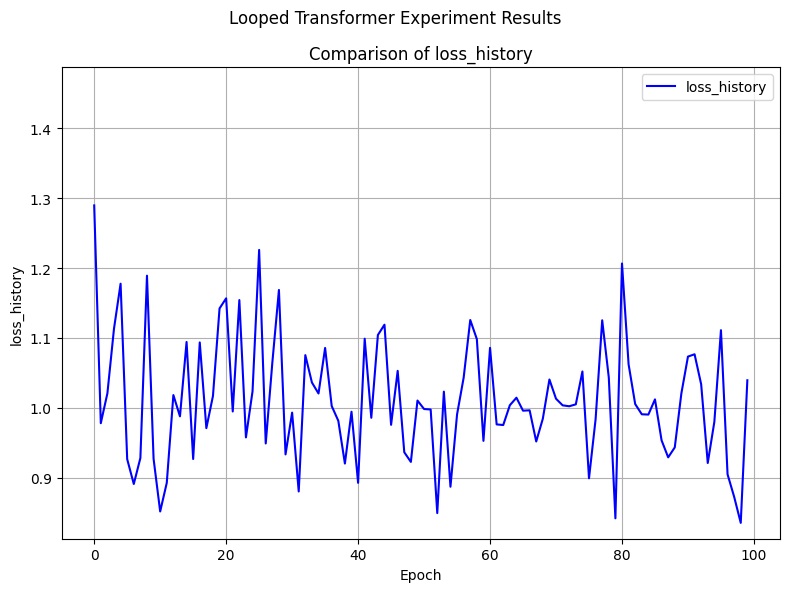

In [182]:
loss_table = ExperimentTable(params_groups=[{'experiment_name': 'loss_history','curriculum': {'d_x': 5, 'seq_len': 10, 'duration_ratio': 0.5}}])
loss_table.run(result_lists=[(['loss_history'], 'epoch')])
loss_table.plot(figure_size=(8,6))

### 绘制 y_pred 和 y_true 的变化曲线

y_norm_error_history initialized in 0.02 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.03 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.03 GB
Epoch 200/1000, Loss: 18.8248, current_blocks: 20
Epoch 400/1000, Loss: 19.7988, current_blocks: 20
Epoch 600/1000, Loss: 17.7491, current_blocks: 20
Epoch 800/1000, Loss: 20.9858, current_blocks: 20
Epoch 1000/1000, Loss: 20.9834, current_blocks: 20
Training completed in 451.35 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 0.03 GB | Metal驱动分配: 2.16 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.04 GB
Experiment 1/1 completed.



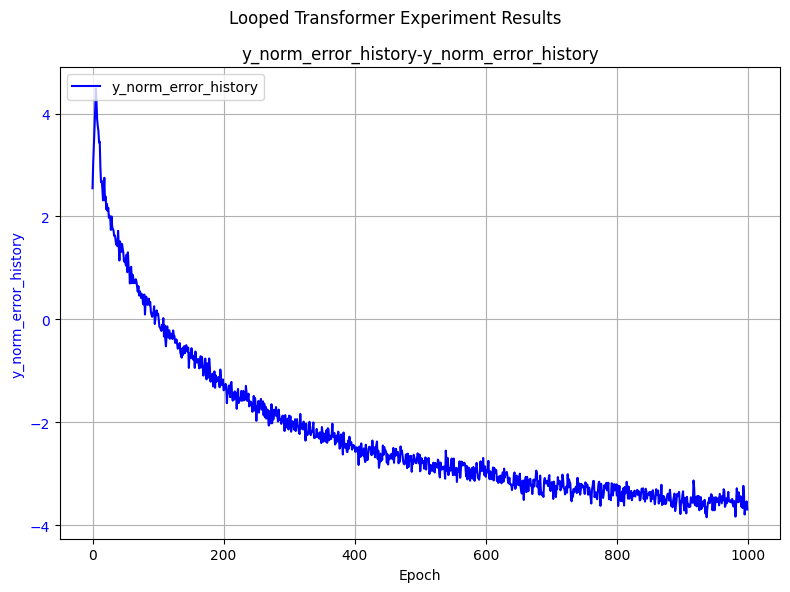

In [75]:
norm_table = ExperimentTable(params_groups=[{'epochs': 1000, 'experiment_name': 'y_norm_error_history', 'print_every': 200}])
norm_table.run(result_lists=[(['y_norm_error_history'], 'epoch')])
norm_table.plot(figure_size=(8,6),compare_experiments=False)

## 对比实验

### Scheduled Training vs Non-Scheduled Training 对比实验

Scheduled Training initialized in 0.02 seconds. Using device: mps
Non-Scheduled Training initialized in 0.01 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.05 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.05 GB
Epoch 5/20, Loss: 63.3171, current_blocks: 19
Epoch 10/20, Loss: 35.1716, current_blocks: 20
Epoch 15/20, Loss: 31.4720, current_blocks: 20
Epoch 20/20, Loss: 28.0077, current_blocks: 20
Training completed in 9.75 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 0.03 GB | Metal驱动分配: 2.16 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.04 GB
Experiment 1/2 completed.

[Experiment 2 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.05 GB
Epoch 5/20, Loss: 68.5955, current_blocks: 20
Epoch 10/20, Loss: 36.3633, current_blocks: 20
Epoch 15/20, Loss: 32.1849, current_blocks: 20
Epoch 20/20, Loss: 28.2660, current_blocks: 20
Training completed in 9.81 seconds.
[Experiment 2 训练峰值] 显存占用 -> PyTorch分配: 0.03 GB | Metal驱动分配: 2.13 

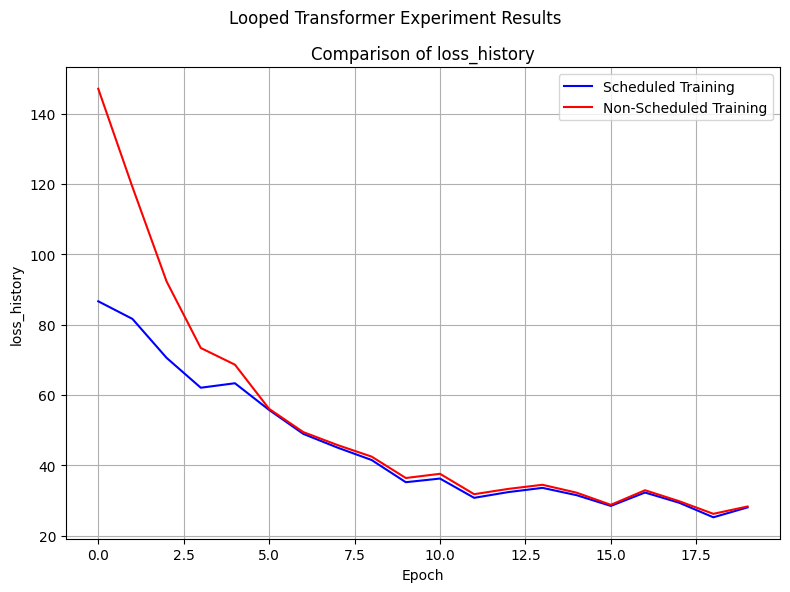

In [76]:
table = ExperimentTable(params_groups=[{'scheduled_training': True, 'experiment_name': 'Scheduled Training'},
                                  {'scheduled_training': False, 'experiment_name': 'Non-Scheduled Training'}])
table.run(result_lists=[(['loss_history'], 'epoch')])
table.plot(figure_size=(8, 6), compare_experiments=True)

### 不同 Positional Embedding 对比实验

Learned APE initialized in 0.02 seconds. Using device: mps
APE initialized in 0.01 seconds. Using device: mps
ALiBi initialized in 0.01 seconds. Using device: mps
RoPE initialized in 0.01 seconds. Using device: mps
MS-UPE initialized in 0.01 seconds. Using device: mps
MS-UPE + Learned APE initialized in 0.01 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 3.10 GB | Metal驱动分配: 4.19 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 3.11 GB | Metal驱动分配: 4.19 GB
Epoch 20/100, Loss: 28.0077, current_blocks: 20
Epoch 40/100, Loss: 20.8999, current_blocks: 20
Epoch 60/100, Loss: 20.2006, current_blocks: 20
Epoch 80/100, Loss: 18.3025, current_blocks: 20
Epoch 100/100, Loss: 21.6682, current_blocks: 20
Training completed in 47.76 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 3.13 GB | Metal驱动分配: 5.22 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 3.10 GB | Metal驱动分配: 4.21 GB
Experiment 1/6 completed.

[Experiment 2 训练前] 显存占用 -> PyTorch分配: 3.11 GB | Metal驱动分配: 4.21 GB
Epoch 20/100, Loss: 25.4152, cur

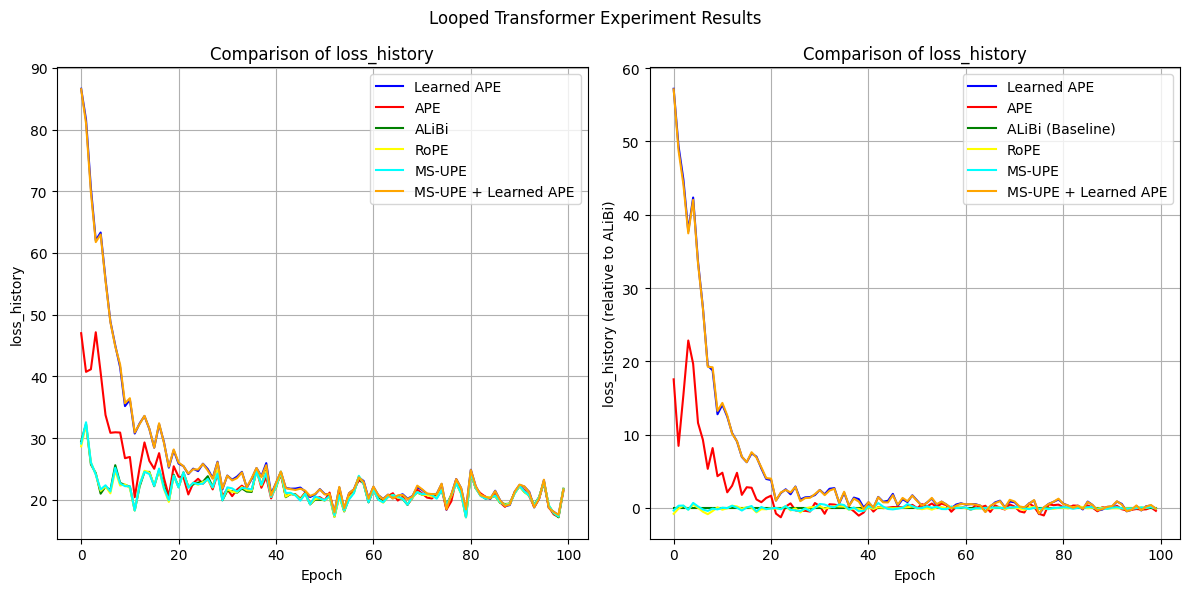

In [79]:
pe_table = ExperimentTable(params_groups=[
    {'pe_type': ['learned_ape'], 'experiment_name': 'Learned APE'},
    {'pe_type': ['ape'], 'experiment_name': 'APE'},
    {'pe_type': ['alibi'], 'experiment_name': 'ALiBi'},
    {'pe_type': ['rope'], 'experiment_name': 'RoPE'},
    {'pe_type': ['ms_upe'], 'experiment_name': 'MS-UPE'},
    {'pe_type': ['ms_upe', 'learned_ape'], 'experiment_name': 'MS-UPE + Learned APE'},
], manual={'epochs': 100, 'print_every': 20})
pe_table.run(result_lists=[
    (['loss_history'], 'epoch'),
    (['loss_history'], 'epoch', 2)  # 以 ALiBi 为基线
])
pe_table.plot(figure_size=(12, 6))

### sink padding 的有无对比实验

Without Sink Padding initialized in 0.02 seconds. Using device: mps
With Sink Padding (1) initialized in 0.01 seconds. Using device: mps
With Sink Padding (2) initialized in 0.01 seconds. Using device: mps
With Sink Padding (5) initialized in 0.01 seconds. Using device: mps
With Sink Padding (10) initialized in 0.01 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 3.10 GB | Metal驱动分配: 4.21 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 3.11 GB | Metal驱动分配: 4.21 GB
Epoch 20/100, Loss: 28.0077, current_blocks: 20
Epoch 40/100, Loss: 20.8999, current_blocks: 20
Epoch 60/100, Loss: 20.2006, current_blocks: 20
Epoch 80/100, Loss: 18.3025, current_blocks: 20
Epoch 100/100, Loss: 21.6682, current_blocks: 20
Training completed in 50.96 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 3.13 GB | Metal驱动分配: 5.22 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 3.10 GB | Metal驱动分配: 4.21 GB
Experiment 1/5 completed.

[Experiment 2 训练前] 显存占用 -> PyTorch分配: 3.11 GB | Metal驱动分配: 4.21 GB
Epoch 20/100, Loss: 28.1

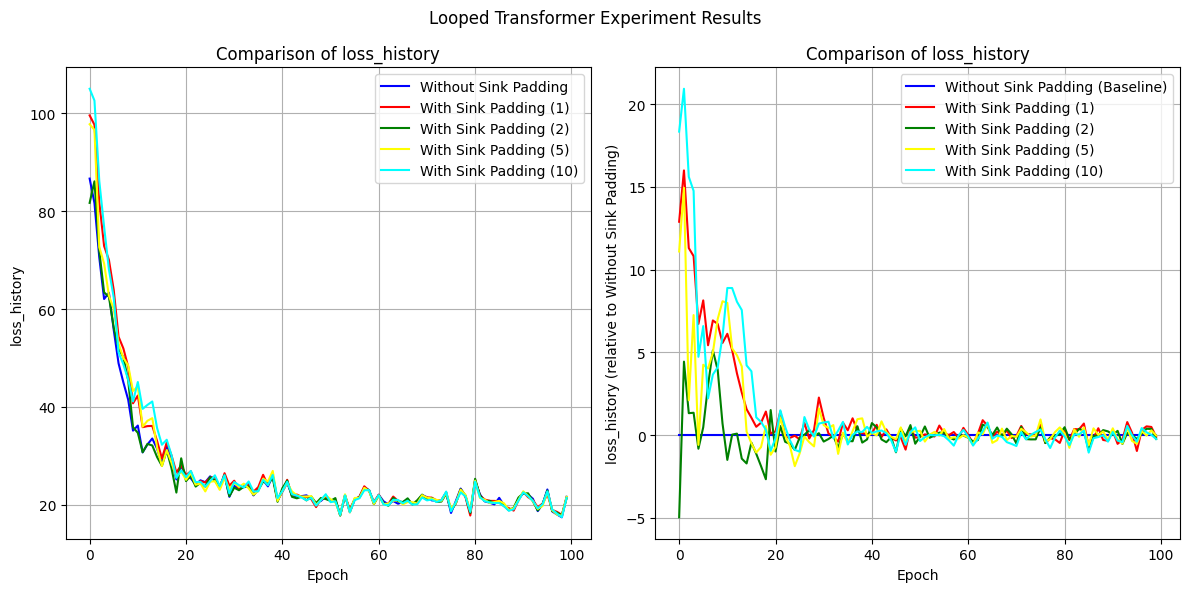

In [80]:
sink_table = ExperimentTable(params_groups=[
    {'experiment_name': 'Without Sink Padding'},
    {'experiment_name': 'With Sink Padding (1)', 'sink_padding': 1},
    {'experiment_name': 'With Sink Padding (2)', 'sink_padding': 2},
    {'experiment_name': 'With Sink Padding (5)', 'sink_padding': 5},
    {'experiment_name': 'With Sink Padding (10)', 'sink_padding': 10},
], manual={'epochs': 100, 'print_every': 20})
sink_table.run(result_lists=[
    (['loss_history'], 'epoch'),
    (['loss_history'], 'epoch', 0),  # 以 Without Sink Padding 为基线
])
sink_table.plot(figure_size=(12, 6))

### Residual Gate 对比实验

No Residual Gate initialized in 0.01 seconds. Using device: mps
Residual Gate (1, 0.5) initialized in 0.01 seconds. Using device: mps
Residual Gate (1, 0.5) Vector initialized in 0.01 seconds. Using device: mps
Residual Gate (1, 0) initialized in 0.01 seconds. Using device: mps
Residual Gate (1, 0) Vector initialized in 0.01 seconds. Using device: mps
Random Learnable Scalar initialized in 0.01 seconds. Using device: mps
Random Learnable Vector initialized in 0.01 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.04 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.04 GB
Epoch 25/50, Loss: 20.7067, current_blocks: 20
Epoch 50/50, Loss: 19.7848, current_blocks: 20
Training completed in 19.79 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 0.03 GB | Metal驱动分配: 2.16 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.03 GB
Experiment 1/7 completed.

[Experiment 2 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.03 GB
Epoch 25/50, Loss: 2

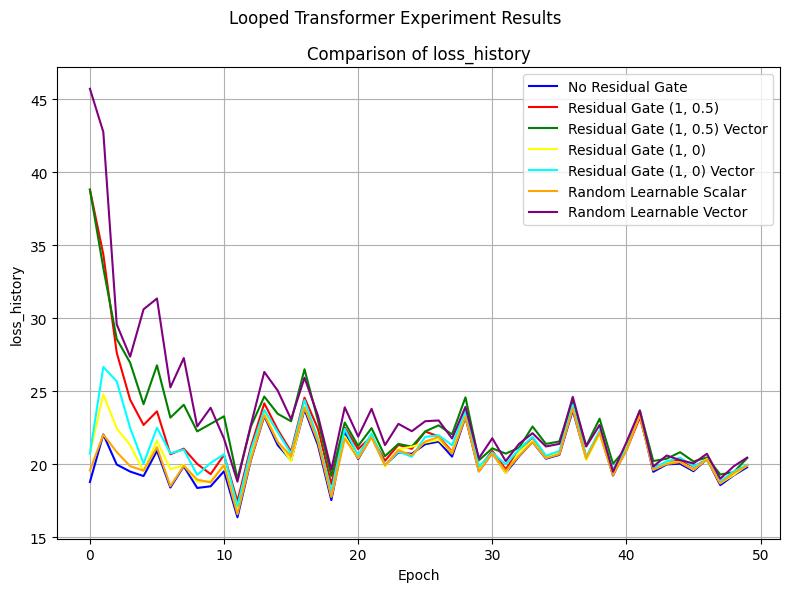

In [27]:
gate_table = ExperimentTable(params_groups=[
    {'experiment_name': 'No Residual Gate', 'residual_gate': (0, 0), 'residual_gate_type': 'fixed'},
    {'experiment_name': 'Residual Gate (1, 0.5)', 'residual_gate': (1, 0.5), 'residual_gate_type': 'learnable_scalar'},
    {'experiment_name': 'Residual Gate (1, 0.5) Vector', 'residual_gate': (1, 0.5), 'residual_gate_type': 'learnable_vector'},
    {'experiment_name': 'Residual Gate (1, 0)', 'residual_gate': (1, 0), 'residual_gate_type': 'learnable_scalar'},
    {'experiment_name': 'Residual Gate (1, 0) Vector', 'residual_gate': (1, 0), 'residual_gate_type': 'learnable_vector'},
    {'experiment_name': 'Random Learnable Scalar', 'residual_gate': 'random', 'residual_gate_type': 'learnable_scalar', 'residual_random': (0.9, 0.1)},
    {'experiment_name': 'Random Learnable Vector', 'residual_gate': 'random', 'residual_gate_type': 'learnable_vector', 'residual_random': (0.9, 0.1)},
], manual={'gate_lr_ratio': 100, 'scheduler_type': 'cosine', 'epochs': 50, 'print_every': 25})
gate_table.run(result_lists=[
    (['loss_history'], 'epoch')
])
gate_table.plot(figure_size=(8, 6))

Residual Gate (1, 0.5) initialized in 0.02 seconds. Using device: mps
Residual Gate (1, 0.5) Vector initialized in 0.01 seconds. Using device: mps
Residual Gate (1, 0) initialized in 0.01 seconds. Using device: mps
Residual Gate (1, 0) Vector initialized in 0.01 seconds. Using device: mps
Random Learnable Scalar initialized in 0.01 seconds. Using device: mps
Random Learnable Vector initialized in 0.01 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.02 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.02 GB
Epoch 25/100, Loss: 21.1192, current_blocks: 20
Epoch 50/100, Loss: 19.8862, current_blocks: 20
Epoch 75/100, Loss: 21.3765, current_blocks: 20
Epoch 100/100, Loss: 20.4947, current_blocks: 20
Training completed in 34.69 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 0.03 GB | Metal驱动分配: 2.16 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.03 GB
Experiment 1/6 completed.

[Experiment 2 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Meta

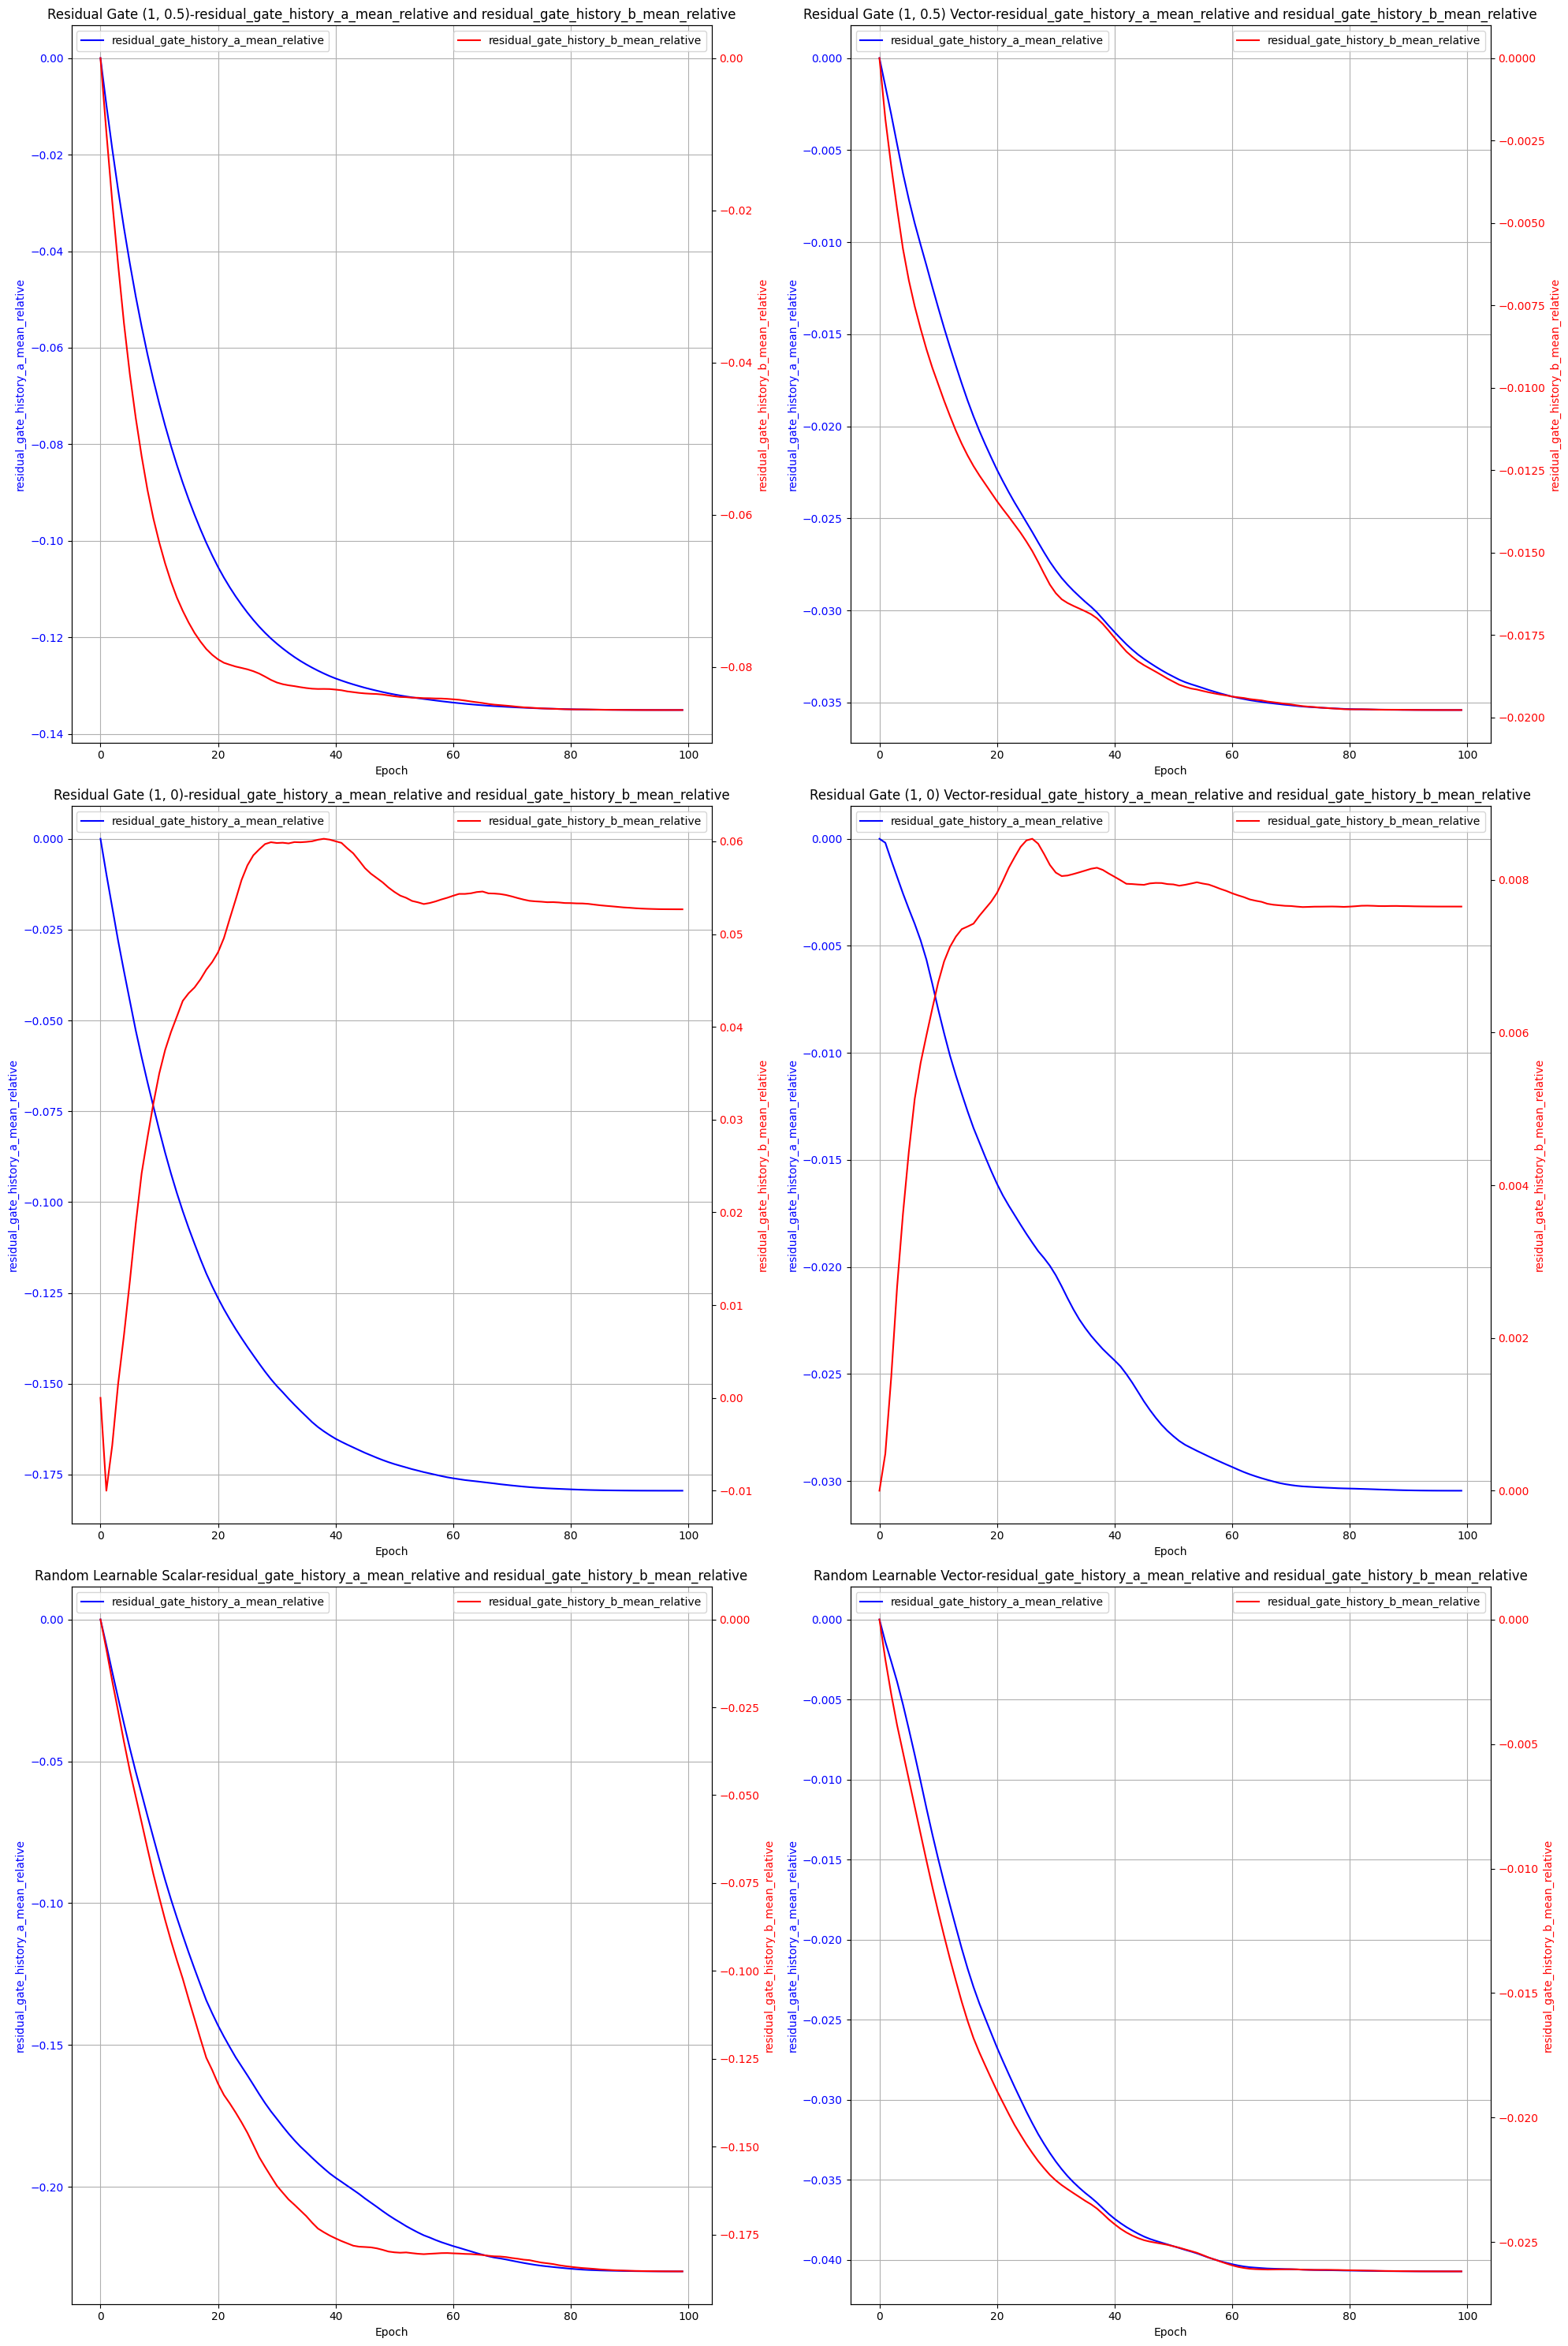

In [26]:
gate_table = ExperimentTable(params_groups=[
    {'experiment_name': 'Residual Gate (1, 0.5)', 'residual_gate': (1, 0.5), 'residual_gate_type': 'learnable_scalar'},
    {'experiment_name': 'Residual Gate (1, 0.5) Vector', 'residual_gate': (1, 0.5), 'residual_gate_type': 'learnable_vector'},
    {'experiment_name': 'Residual Gate (1, 0)', 'residual_gate': (1, 0), 'residual_gate_type': 'learnable_scalar'},
    {'experiment_name': 'Residual Gate (1, 0) Vector', 'residual_gate': (1, 0), 'residual_gate_type': 'learnable_vector'},
    {'experiment_name': 'Random Learnable Scalar', 'residual_gate': 'random', 'residual_gate_type': 'learnable_scalar', 'residual_random': (0.9, 0.1)},
    {'experiment_name': 'Random Learnable Vector', 'residual_gate': 'random', 'residual_gate_type': 'learnable_vector', 'residual_random': (0.9, 0.1)},
], manual={'gate_lr_ratio': 100, 'scheduler_type': 'cosine', 'epochs': 100, 'print_every': 25})
gate_table.run(result_lists=[
    (['residual_gate_history_a_mean_relative', 'residual_gate_history_b_mean_relative'], 'epoch')
])
gate_table.plot(figure_size=(20,30),compare_experiments=False, subplot_shape=(-1,2), suptitle='')

### 不同scheduler对比实验

No Scheduler initialized in 0.02 seconds. Using device: mps
Cosine Scheduler initialized in 0.01 seconds. Using device: mps
Step Scheduler initialized in 0.01 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.04 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.04 GB
Epoch 50/200, Loss: 19.8760, current_blocks: 20
Epoch 100/200, Loss: 21.0343, current_blocks: 20
Epoch 150/200, Loss: 19.6615, current_blocks: 20
Epoch 200/200, Loss: 18.4375, current_blocks: 20
Training completed in 66.28 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 0.02 GB | Metal驱动分配: 2.13 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.07 GB
Experiment 1/3 completed.

[Experiment 2 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.08 GB
Epoch 50/200, Loss: 19.8793, current_blocks: 20
Epoch 100/200, Loss: 21.0404, current_blocks: 20
Epoch 150/200, Loss: 19.6585, current_blocks: 20
Epoch 200/200, Loss: 18.4290, current_blocks: 20
Training completed in 64.98 second

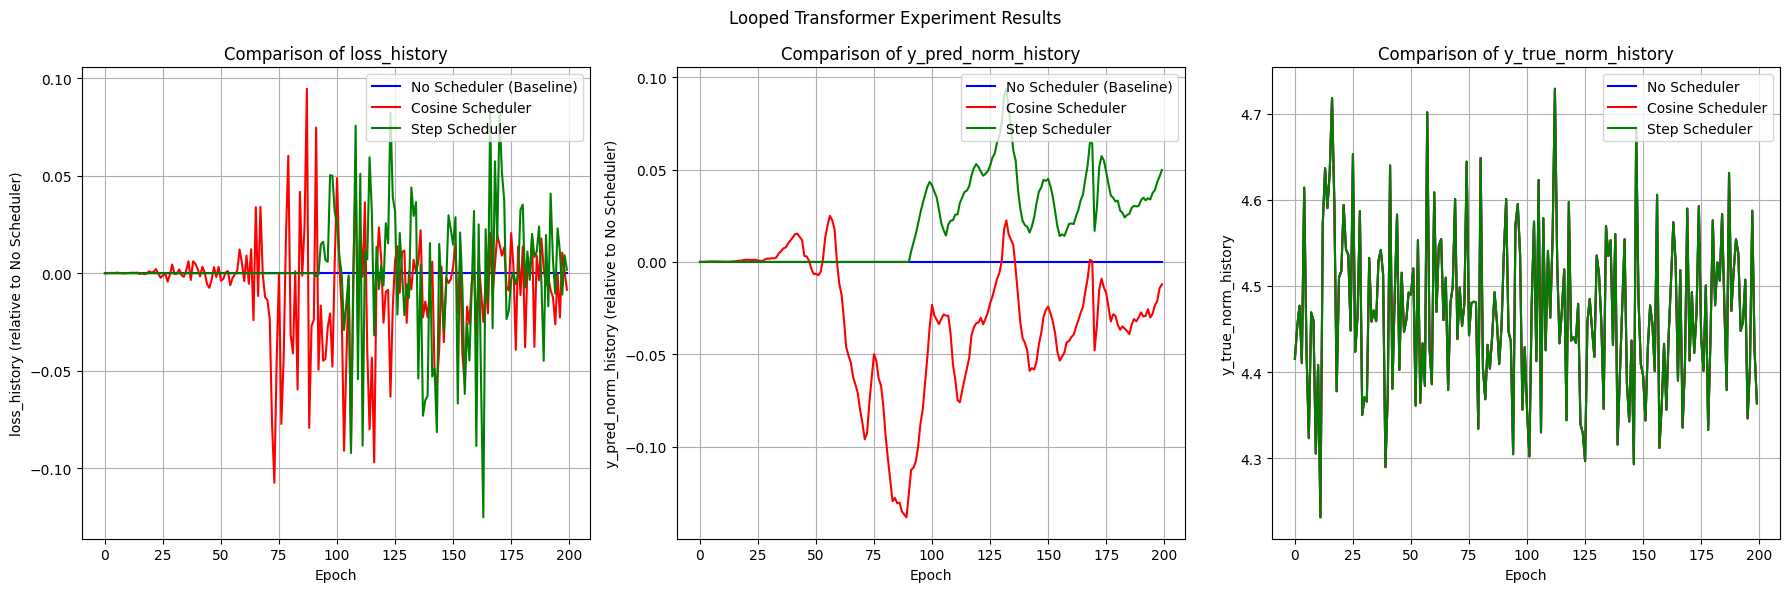

In [28]:
experiment_table = ExperimentTable(params_groups=[{'experiment_name': 'No Scheduler'},
                                                  {'scheduler_type': 'cosine', 'experiment_name': 'Cosine Scheduler', 'lr_scale': 0},
                                                  {'scheduler_type': 'step', 'experiment_name': 'Step Scheduler', 'lr_scale': 0.1, 'step_size_scheduler': 90}],
    manual={'epochs':200, 'lr': 1e-3, 'optimizer_type': 'adamw', 'pe_type': ['alibi'],
    'wd_adamw': 0.2, 'd_model': 32, 'num_heads': 1, 'max_seq_len': 500, 'seq_len': 400, 'batch_size': 64, 'd_x': 20, 
    'num_blocks': 20, 'num_eff': 15, 
    'residual_gate': (1,1), 'residual_gate_type': 'learnable_scalar', 'gate_lr_ratio': 100,
    'scheduler_type': None, 'lr_scale': 0.01, 'step_size_scheduler': 10,
    'print_every': 50,
    'layer_weight_decay': 0.8, 'seq_weight_decay': 0.9
    })
experiment_table.run(result_lists=[(['loss_history'], 'epoch', 0), (['y_pred_norm_history'], 'epoch', 0), (['y_true_norm_history'], 'epoch')])
experiment_table.plot(figure_size=(18, 6))

# Non-linear Regression Experiments

## 实验数据观测

In [70]:
manual=dict(
    data_type='nonlinear',
    function_callable=lambda x: F.relu(x),
    max_seq_len=500,
    scheduled_training=True,
    pe_type=['alibi'],
    residual_gate=(1, 0.5),
    residual_gate_type='learnable_scalar',
    num_eff=5,
    num_blocks=20,
    batch_size=8,
    num_heads=2,
    d_model=128,
    seq_len=400,
    d_hidden=8,
    epochs=100)



loss_history initialized in 0.02 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.22 GB | Metal驱动分配: 0.28 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.22 GB | Metal驱动分配: 0.28 GB
Epoch 100/500, Loss: 0.4739, Norm Ratio: 0.4741, Current Blocks: 20
Epoch 200/500, Loss: 0.3862, Norm Ratio: 0.6557, Current Blocks: 20
Epoch 300/500, Loss: 0.6595, Norm Ratio: 0.5505, Current Blocks: 20
Epoch 400/500, Loss: 0.3205, Norm Ratio: 0.5234, Current Blocks: 20
Epoch 500/500, Loss: 0.3823, Norm Ratio: 0.5465, Current Blocks: 20
Training completed in 51.75 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 0.23 GB | Metal驱动分配: 0.93 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.22 GB | Metal驱动分配: 0.29 GB
Experiment 1/1 completed.



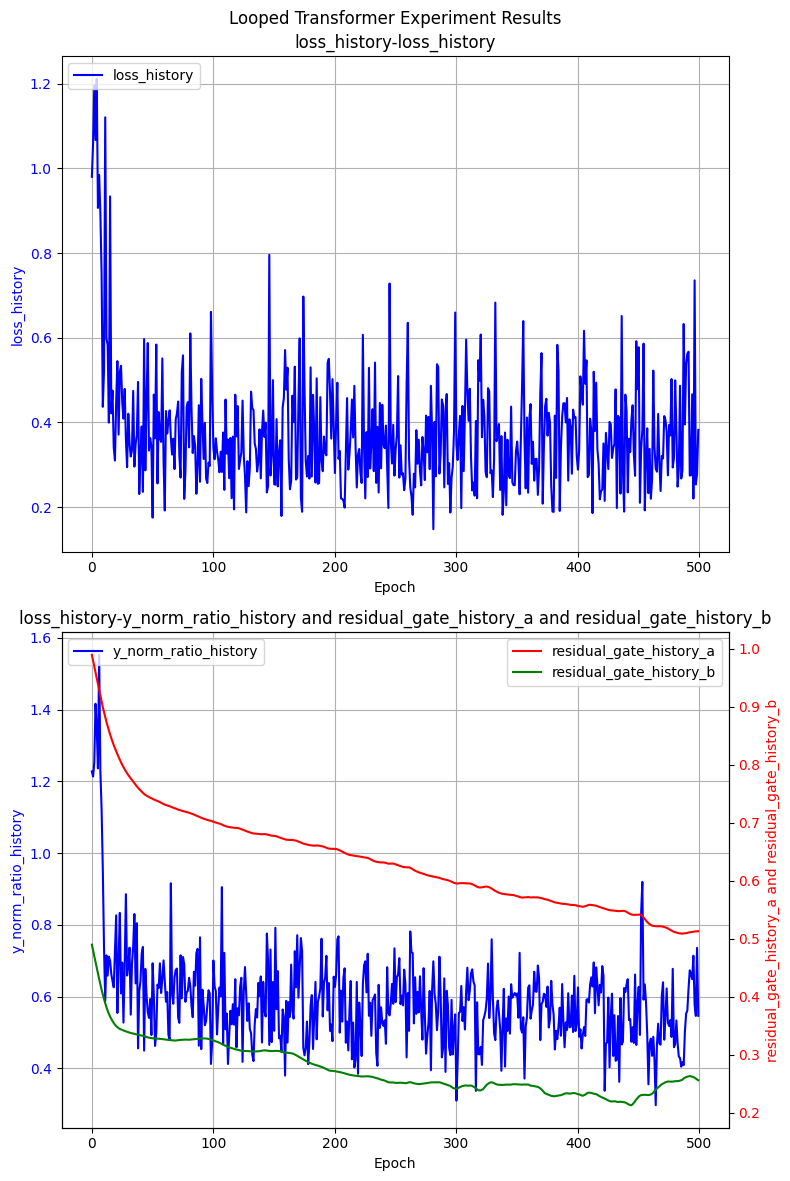

In [31]:
loss_table = ExperimentTable(params_groups=[{'experiment_name': 'loss_history',
                                             'epochs': 500,
                                             'print_every': 100}], manual=manual)
loss_table.run(result_lists=[(['loss_history'], 'epoch'), (['y_norm_ratio_history', 'residual_gate_history_a', 'residual_gate_history_b'], 'epoch')])
loss_table.plot(figure_size=(8,12), compare_experiments=False, subplot_shape=(-1,1))

loss_history initialized in 0.02 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.28 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.28 GB
Epoch 5/50, Loss: 0.3561, Norm Ratio: 0.5421, Current Blocks: 9
Epoch 10/50, Loss: 0.3383, Norm Ratio: 0.5416, Current Blocks: 14
Epoch 15/50, Loss: 0.3495, Norm Ratio: 0.5456, Current Blocks: 19
Epoch 20/50, Loss: 0.3471, Norm Ratio: 0.5498, Current Blocks: 20
Epoch 25/50, Loss: 0.3525, Norm Ratio: 0.5475, Current Blocks: 20
Epoch 30/50, Loss: 0.3495, Norm Ratio: 0.5437, Current Blocks: 20
Epoch 35/50, Loss: 0.3371, Norm Ratio: 0.5565, Current Blocks: 20
Epoch 40/50, Loss: 0.3466, Norm Ratio: 0.5229, Current Blocks: 20
Epoch 45/50, Loss: 0.3412, Norm Ratio: 0.5482, Current Blocks: 20
Epoch 50/50, Loss: 0.3425, Norm Ratio: 0.5409, Current Blocks: 20
Training completed in 1039.72 seconds.
[Experiment 1 训练峰值] 显存占用 -> PyTorch分配: 0.02 GB | Metal驱动分配: 0.70 GB
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.00 GB | Met

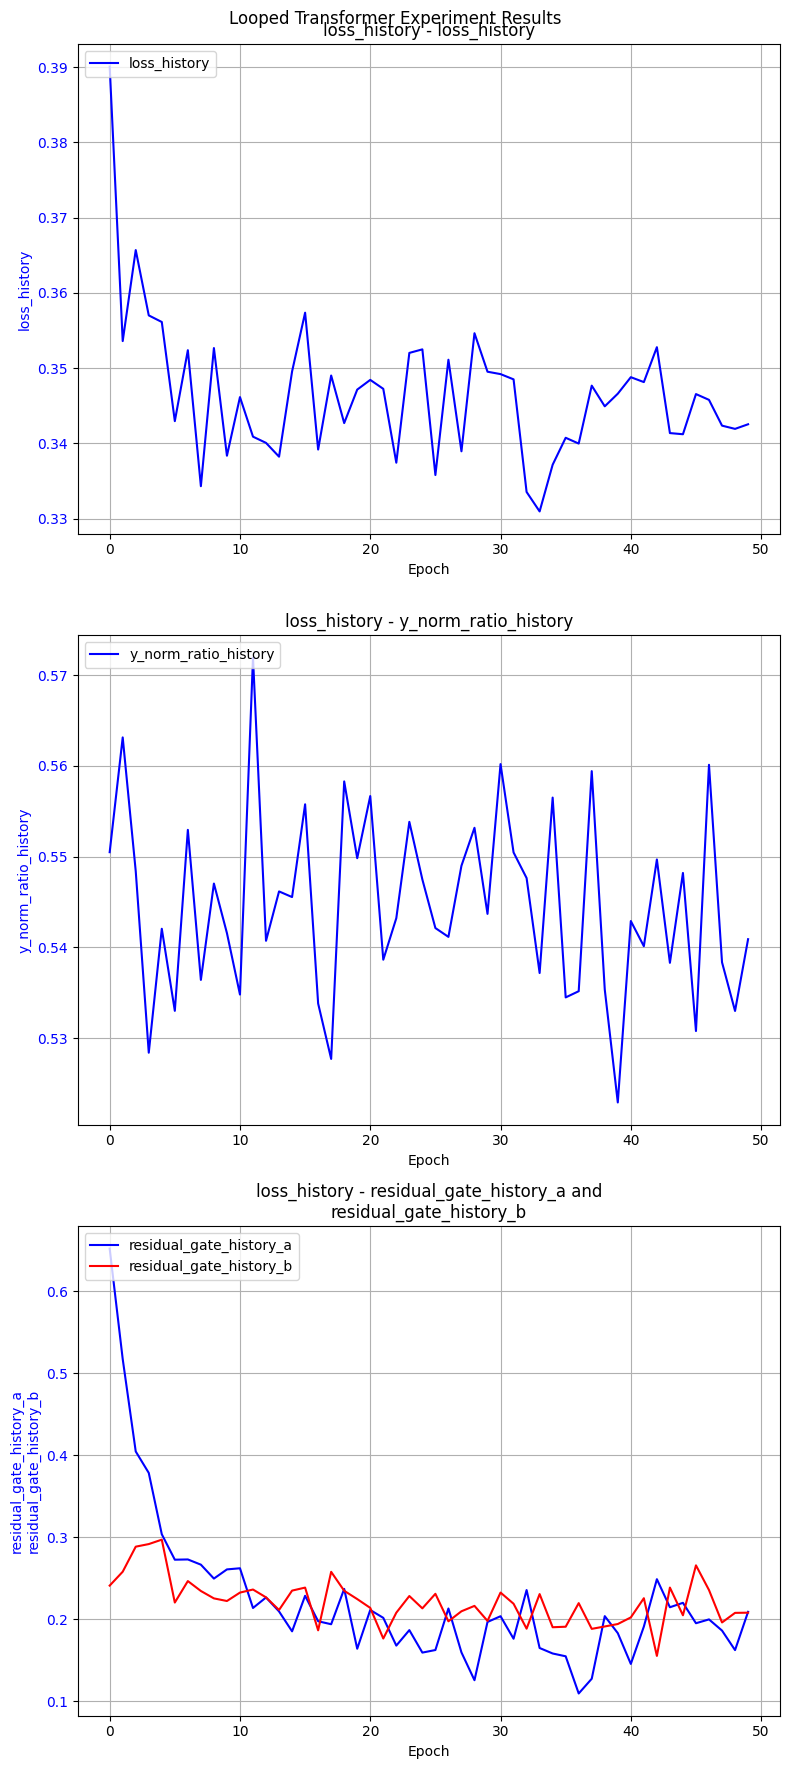

In [95]:
loss_table = ExperimentTable(params_groups=[{'experiment_name': 'loss_history',
                                             'epochs': 50,
                                             'steps_per_epoch': 200,
                                             'init_std': 'auto',
                                             'print_every': 5}], manual=manual)
loss_table.run(result_lists=[(['loss_history'], 'epoch'), (['y_norm_ratio_history'], 'epoch'), (['residual_gate_history_a', 'residual_gate_history_b', '|'], 'epoch')])
loss_table.plot(compare_experiments=False, subplot_shape=(-1,1))

**实验数据分析**
1. 参数量分析
2. norm_ratio与loss的关系分析
  - 对于Linear+ReLU+Linear，由于Linear矩阵归一化后方差为1，ReLU又会丢掉一半的激活，因此y_true的二阶矩（能量）期望为 $\mathbb{E}[y^2] \approx 0.5$
  - 模型在进行 In-Context Learning (ICL) 时，遇到了认知瓶颈。它把复杂的真实信号 y 拆解成了两个部分：$y=y_{learnable}+y_{noise}$
    - $y_{learnable}$：模型通过现有的上下文能够学明白的“低频/线性”规律。
    - $y_{noise}$：由于非线性过于复杂或上下文信息仍显不足，模型无法解开的“高频/非线性”残差。
  - 在 MSE 损失函数的逼迫下，模型最聪明的做法就是精准预测自己能看懂的部分，对看不懂的部分直接输出 0。因此它的预测值 $\hat{y} \approx y_{learnable}$。
  - 根据 Norm Ratio 倒推 loss：
    - 观察到 Norm Ratio 在 0.54 附近震荡，即
    $$Norm Ratio = \sqrt{\frac{\mathbb{E}[\hat{y}^2]}{\mathbb{E}[y^2]}} \approx \sqrt{\frac{\mathbb{E}[y_{learnable}^2]}{\mathbb{E}[y_{learnable}^2]+ \mathbb{E}[y_{noise}^2]}} \approx 0.54$$
    - 代入 $\mathbb{E}[y^2] \approx 0.5$，可以推断出 $\mathbb{E}[y_{learnable}^2] \approx 0.14$，$\mathbb{E}[y_{noise}^2] \approx 0.36$。
    - 由于 $\hat{y} \to y_{learnable}$，因此最终的 loss 约为 
      $$\mathbb{E}[(y-\hat{y})^2] = \mathbb{E}[y_{noise}^2] + \mathbb{E}[(y_{learnable}-\hat{y})^2] \approx 0.36$$
      与实际观察到的 loss 值相近。

# Curriculum Learning 实验

## linear

### 训练10000步

Without Curriculum (Hard Mode) initialized in 0.03 seconds. Using device: mps
With Curriculum (Perfect Path) initialized in 0.02 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.04 GB | Metal驱动分配: 1.03 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.05 GB | Metal驱动分配: 1.03 GB
Epoch 1/50, Loss: 1.0582, Norm Ratio: 0.1946, Avg Sink Score: 0.0655, Avg Sink Rate: 0.0000
Epoch 2/50, Loss: 1.0064, Norm Ratio: 0.0913, Avg Sink Score: 0.0636, Avg Sink Rate: 0.0000
Epoch 3/50, Loss: 1.0058, Norm Ratio: 0.0701, Avg Sink Score: 0.0629, Avg Sink Rate: 0.0000
Epoch 4/50, Loss: 1.0001, Norm Ratio: 0.0598, Avg Sink Score: 0.0622, Avg Sink Rate: 0.0000
Epoch 5/50, Loss: 1.0026, Norm Ratio: 0.0482, Avg Sink Score: 0.0622, Avg Sink Rate: 0.0000
Epoch 6/50, Loss: 0.9974, Norm Ratio: 0.0422, Avg Sink Score: 0.0621, Avg Sink Rate: 0.0000
Epoch 7/50, Loss: 1.0029, Norm Ratio: 0.0469, Avg Sink Score: 0.0620, Avg Sink Rate: 0.0000
Epoch 8/50, Loss: 0.9991, Norm Ratio: 0.0409, Avg Sink Score: 0.0618, Avg Si

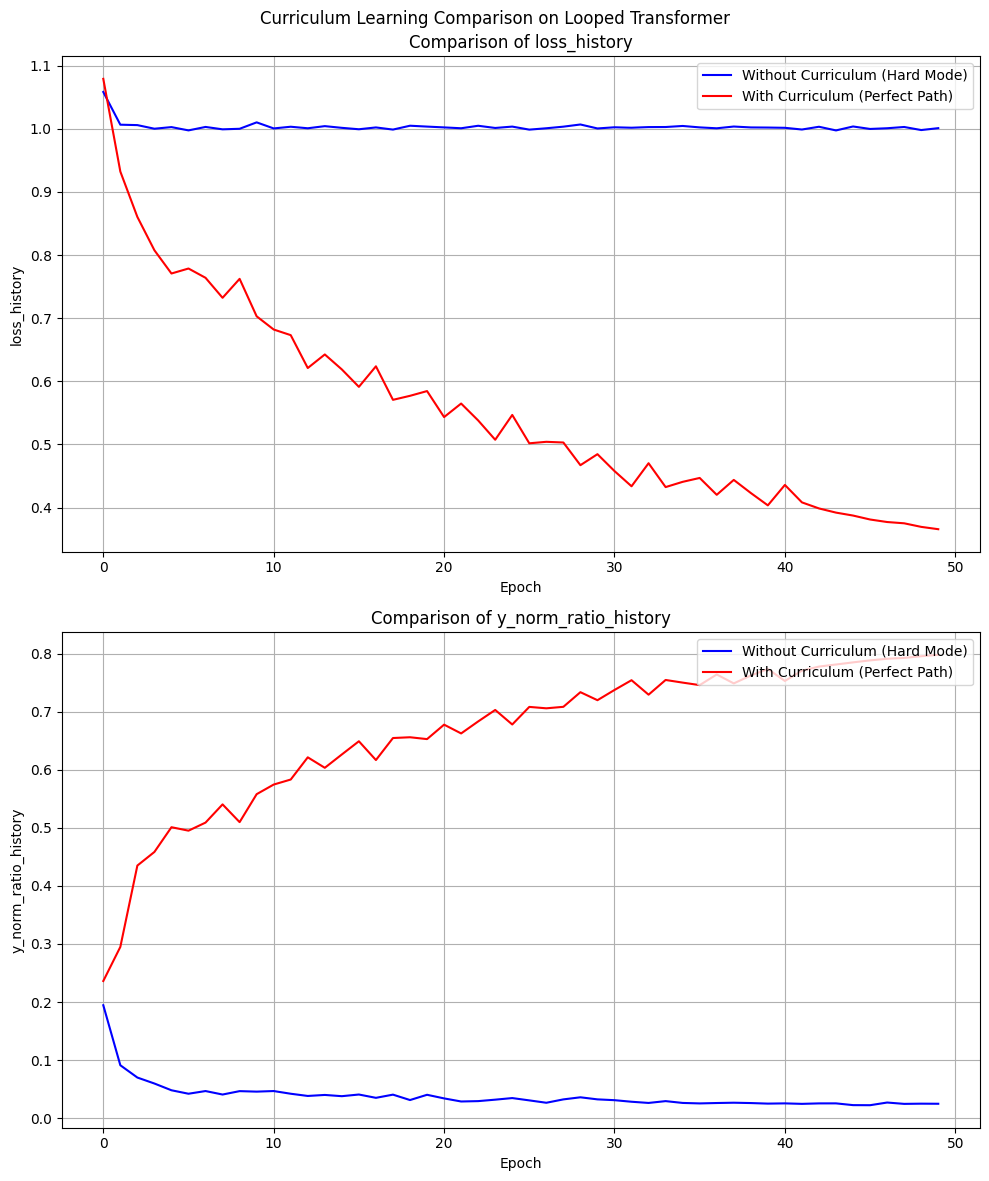

In [ ]:
manual_config = dict(
    # 任务基础配置
    data_type='linear',
    d_x=20,
    seq_len=80,
    batch_size=64,
    
    # 模型架构 (完全对齐论文)
    num_blocks=20,
    num_eff=15,
    d_model=256,
    num_heads=8,
    pe_type=['learned_ape'],
    
    # 核心物理机制配置
    x_init='zero',               # 绝对零起点
    init_std='auto',             # 方差自适应 (1/sqrt(256))
    residual_gate=(1, 1),        # 标准注入
    residual_gate_type='fixed',
    
    # 优化器剥离外挂
    optimizer_type='adam', 
    lr=1e-4,
    layer_weight_decay=1.0,      # 关闭层级惩罚
    seq_weight_decay=1.0,        # 关闭时间步惩罚
    scheduler_type=None,         # 恒定学习率
    
    # 运行控制
    epochs=50,
    steps_per_epoch=200,
    print_every=1,
    
    scheduled_training=True      # 开启 b 的 Kick-start
)

# === 定义并执行实验表 ===
final_table = ExperimentTable(params_groups=[
    {
        'experiment_name': 'Without Curriculum (Hard Mode)',
        'curriculum': {} # 空字典关闭课程学习
    },
    {
        'experiment_name': 'With Curriculum (Perfect Path)',
        'curriculum': {
            'd_x': 5, 
            'seq_len': 10, 
            'duration_ratio': 0.8 # 前 40 个 epoch 完成课程
        }
    }
], manual=manual_config)

final_table.run(result_lists=[(['loss_history'], 'epoch'), (['y_norm_ratio_history'], 'epoch')])
final_table.plot(figure_size=(10, 12), compare_experiments=True, subplot_shape=(-1, 1), suptitle='Curriculum Learning Comparison on Looped Transformer')

### 保存模型权重

In [212]:
import torch
import os
os.makedirs('saved_checkpoints', exist_ok=True)
print("正在保存模型权重...")
for i, exp in enumerate(final_table.experiments):
    exp_name = final_table.init_parameters[i].get('experiment_name', f'Experiment_{i}')
    # 清理文件名中的特殊字符
    safe_name = exp_name.replace(' ', '_').replace('(', '').replace(')', '')
    save_path = f'saved_checkpoints/{safe_name}.pth'
    checkpoint = {
        'model_state_dict': exp.model.state_dict(),
        'loss_history': getattr(exp, 'loss_history', []),
        'y_pred_norm_history': getattr(exp, 'y_pred_norm_history', []),
        'y_true_norm_history': getattr(exp, 'y_true_norm_history', []),
        'sink_score_history': getattr(exp, 'sink_score_history', []),
        'sink_rate_history': getattr(exp, 'sink_rate_history', []),
        'residual_gate_history': getattr(exp, 'residual_gate_history', []),
    }
    if hasattr(exp, 'optimizer'):
        checkpoint['optimizer_state_dict'] = exp.optimizer.state_dict()
    torch.save(checkpoint, save_path)
    print(f"✅ Checkpoint 已安全保存至: {save_path}")

正在保存模型权重...
✅ Checkpoint 已安全保存至: saved_checkpoints/Nonlinear_Without_Curriculum_Hard_Mode.pth
✅ Checkpoint 已安全保存至: saved_checkpoints/Nonlinear_With_Curriculum_Perfect_Path.pth


### 加载模型、评估结果

检测到纯权重 state_dict 文件（或历史版本），直接加载 model_state_dict...
🔄 成功从 saved_checkpoints/Without_Curriculum_Hard_Mode_weights.pth 恢复实验状态。
Linear Without Curriculum (Hard Mode) initialized in 0.06 seconds. Using device: mps
检测到纯权重 state_dict 文件（或历史版本），直接加载 model_state_dict...
🔄 成功从 saved_checkpoints/With_Curriculum_Perfect_Path_weights.pth 恢复实验状态。
Linear With Curriculum (Perfect Path) initialized in 0.03 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.11 GB | Metal驱动分配: 2.07 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.11 GB | Metal驱动分配: 2.07 GB
[1_ID_Baseline] Loss: 0.7418, Norm Ratio: 0.0097
[2_OOD_Scale_x2] Loss: 4.5082, Norm Ratio: 0.0054
[3_OOD_Seq_Extrapolation] Loss: 1.1665, Norm Ratio: 0.0102
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.13 GB | Metal驱动分配: 2.07 GB
Experiment 1/2 completed.

[Experiment 2 训练前] 显存占用 -> PyTorch分配: 0.14 GB | Metal驱动分配: 2.07 GB
[1_ID_Baseline] Loss: 0.0728, Norm Ratio: 1.0402
[2_OOD_Scale_x2] Loss: 0.5680, Norm Ratio: 0.8993
[3_OOD_Seq_Extrapolation] Loss: 0.09

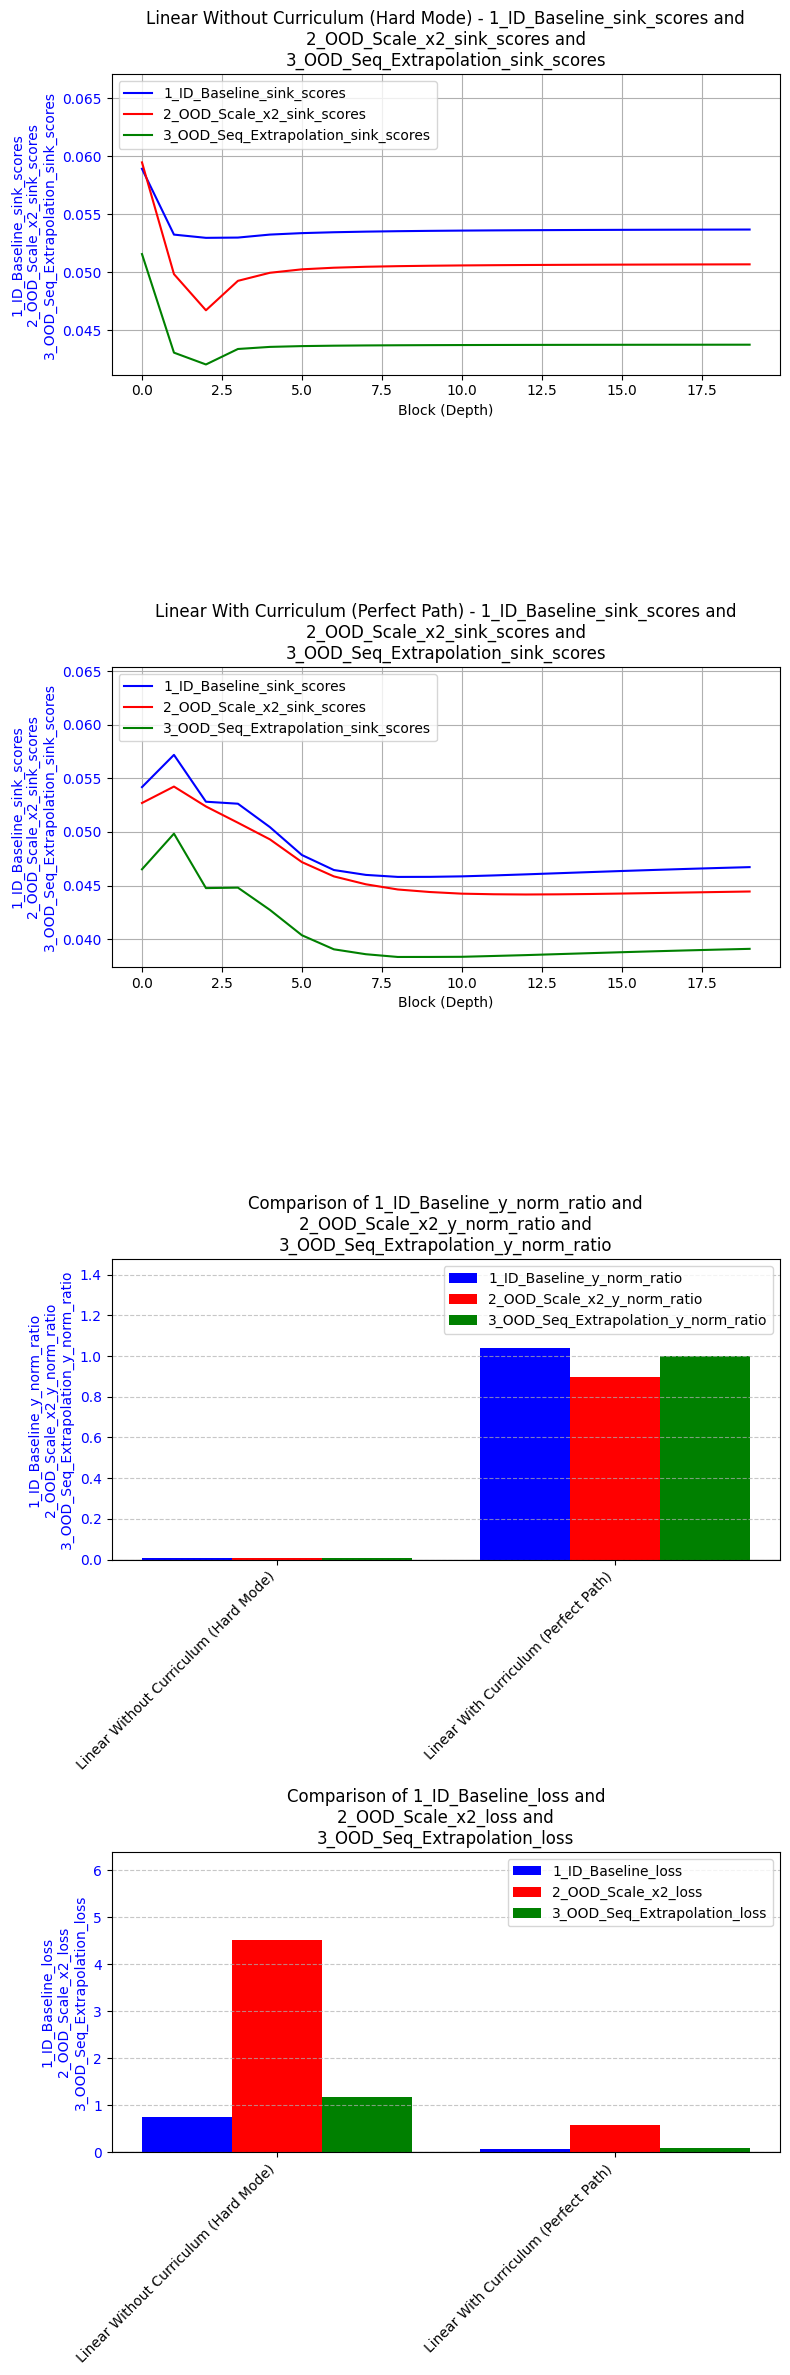

In [ ]:
manual_config = dict(
    # 任务基础配置
    data_type='linear',
    d_x=20,
    seq_len=80,
    batch_size=64,
    
    # 模型架构 (完全对齐论文)
    num_blocks=20,
    num_eff=15,
    d_model=256,
    num_heads=8,
    pe_type=['learned_ape'],
    
    # 核心物理机制配置
    x_init='zero',               # 绝对零起点
    init_std='auto',             # 方差自适应 (1/sqrt(256))
    residual_gate=(1, 1),        # 标准注入
    residual_gate_type='fixed',
    
    # 优化器剥离外挂
    optimizer_type='adam', 
    lr=1e-4,
    layer_weight_decay=1.0,      # 关闭层级惩罚
    seq_weight_decay=1.0,        # 关闭时间步惩罚
    scheduler_type=None,         # 恒定学习率
    
    # 运行控制
    epochs=50,
    steps_per_epoch=200,
    print_every=1,
    
    scheduled_training=True      # 开启 b 的 Kick-start
)

test_table = ExperimentTable(params_groups=[
    {
        'experiment_name': 'Linear Without Curriculum (Hard Mode)',
        'curriculum': {}, # 空字典关闭课程学习
        'load_path': 'saved_checkpoints/Without_Curriculum_Hard_Mode_weights.pth'
    },
    {
        'experiment_name': 'Linear With Curriculum (Perfect Path)',
        'curriculum': {
            'd_x': 5, 
            'seq_len': 10, 
            'duration_ratio': 0.8 # 前 40 个 epoch 完成课程
        },
        'load_path': 'saved_checkpoints/With_Curriculum_Perfect_Path_weights.pth'
    }
], manual=manual_config)

results_lists = [
    (['1_ID_Baseline_sink_scores','2_OOD_Scale_x2_sink_scores', '3_OOD_Seq_Extrapolation_sink_scores'], 'block'),
    (['1_ID_Baseline_y_norm_ratio', '2_OOD_Scale_x2_y_norm_ratio', '3_OOD_Seq_Extrapolation_y_norm_ratio'], 'experiment'),
    (['1_ID_Baseline_loss', '2_OOD_Scale_x2_loss', '3_OOD_Seq_Extrapolation_loss'], 'experiment')
]
    
eval_configs = [
    {'eval_name': '1_ID_Baseline', 'ood_kwargs': {}}, # 分布内基准
    {'eval_name': '2_OOD_Scale_x2', 'ood_kwargs': {'x_scale': 2.0}}, # X 尺度放大（测试抗干扰）
    {'eval_name': '3_OOD_Seq_Extrapolation', 'ood_kwargs': {'seq_len_scale': 1.2}} # 序列长度外推（测试算法泛化）
]
test_table.run(result_lists=results_lists, modes=['evaluate'], eval_configs=eval_configs)
test_table.plot(compare_experiments=False, subplot_shape=(-1,1),suptitle='')

## nonlinear

### 任务配置

In [60]:
manual_config = dict(
    # 任务基础配置
    data_type='nonlinear',
    function_callable=lambda x: 2**0.5 *F.relu(x),
    max_seq_len=200,
    d_x=20,
    seq_len=80,
    batch_size=64,
    
    # 模型架构 (完全对齐论文)
    num_blocks=20,
    num_eff=15,
    d_model=256,
    num_heads=8,
    pe_type=['learned_ape'],
    
    # 核心物理机制配置
    x_init='zero',               # 绝对零起点
    init_std='auto',             # 方差自适应 (1/sqrt(256))
    residual_gate=(1, 1),        # 标准注入
    residual_gate_type='fixed',
    
    # 优化器剥离外挂
    optimizer_type='adam', 
    lr=1e-4,
    layer_weight_decay=1.0,      # 关闭层级惩罚
    seq_weight_decay=1.0,        # 关闭时间步惩罚
    scheduler_type=None,         # 恒定学习率
    
    # 运行控制
    epochs=50,
    steps_per_epoch=200,
    print_every=5,
    
    scheduled_training=True,      # 开启 b 的 Kick-start
    save_path='auto',
    load_path='auto'
)

param_groups = [
    {
        'experiment_name': 'Nonlinear Without Curriculum (Hard Mode)',
        'curriculum': {} # 空字典关闭课程学习
    },
    {
        'experiment_name': 'Nonlinear With Curriculum (Perfect Path)',
        'curriculum': {
            'd_x': 5, 
            'seq_len': 10, 
            'duration_ratio': 0.8 # 前 40 个 epoch 完成课程
        }
    }
]
results_lists = [
    (['1_ID_Baseline_sink_scores','2_OOD_Scale_x2_sink_scores', '3_OOD_Seq_Extrapolation_sink_scores'], 'block'),
    (['1_ID_Baseline_y_norm_ratio', '2_OOD_Scale_x2_y_norm_ratio', '3_OOD_Seq_Extrapolation_y_norm_ratio'], 'experiment'),
    (['1_ID_Baseline_loss', '2_OOD_Scale_x2_loss', '3_OOD_Seq_Extrapolation_loss'], 'experiment')
]
    
eval_configs = [
    {'eval_name': '1_ID_Baseline', 'ood_kwargs': {}}, # 分布内基准
    {'eval_name': '2_OOD_Scale_x2', 'ood_kwargs': {'x_scale': 2.0}}, # X 尺度放大（测试抗干扰）
    {'eval_name': '3_OOD_Seq_Extrapolation', 'ood_kwargs': {'seq_len_scale': 1.2}} # 序列长度外推（测试算法泛化）
]

### 训练

⚠️ 找不到文件 saved_checkpoints/Nonlinear_Without_Curriculum_Hard_Mode.pth，跳过加载。
Nonlinear Without Curriculum (Hard Mode) initialized in 0.49 seconds. Using device: mps
⚠️ 找不到文件 saved_checkpoints/Nonlinear_With_Curriculum_Perfect_Path.pth，跳过加载。
Nonlinear With Curriculum (Perfect Path) initialized in 0.02 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.02 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.02 GB
Epoch 5/50, Loss: 0.7411, Norm Ratio: 0.5209, Avg Sink Score: 0.0620, Avg Sink Rate: 0.0000
Epoch 10/50, Loss: 0.7376, Norm Ratio: 0.5189, Avg Sink Score: 0.0683, Avg Sink Rate: 0.0000
Epoch 15/50, Loss: 0.7305, Norm Ratio: 0.5225, Avg Sink Score: 0.0745, Avg Sink Rate: 0.0000
Epoch 20/50, Loss: 0.7315, Norm Ratio: 0.5204, Avg Sink Score: 0.0926, Avg Sink Rate: 0.0000
Epoch 25/50, Loss: 0.7207, Norm Ratio: 0.5260, Avg Sink Score: 0.0901, Avg Sink Rate: 0.0000
Epoch 30/50, Loss: 0.6593, Norm Ratio: 0.5865, Avg Sink Score: 0.0537, Avg Sink Rate

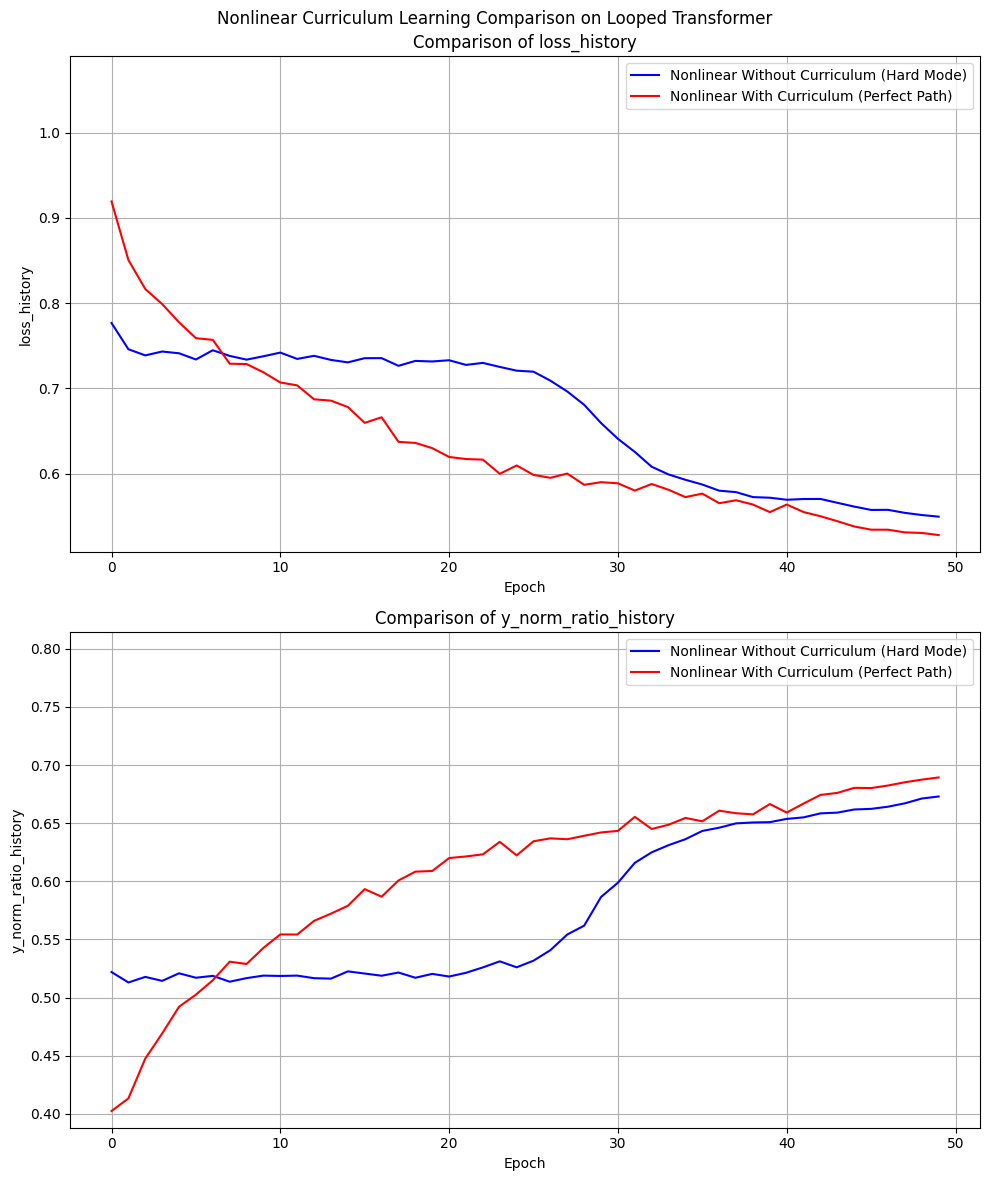

In [26]:
nonlinear_table = ExperimentTable(params_groups=param_groups, manual=manual_config)
nonlinear_table.run(result_lists=[(['loss_history'], 'epoch'), (['y_norm_ratio_history'], 'epoch')])
nonlinear_table.plot(figure_size=(10, 12), compare_experiments=True, subplot_shape=(-1, 1), suptitle='Nonlinear Curriculum Learning Comparison on Looped Transformer')

### 评估

🔄 成功从 saved_checkpoints/Nonlinear_Without_Curriculum_Hard_Mode.pth 恢复实验状态。
Nonlinear Without Curriculum (Hard Mode) initialized in 0.10 seconds. Using device: mps
🔄 成功从 saved_checkpoints/Nonlinear_With_Curriculum_Perfect_Path.pth 恢复实验状态。
Nonlinear With Curriculum (Perfect Path) initialized in 0.03 seconds. Using device: mps
[本底显存检测] 显存占用 -> PyTorch分配: 0.00 GB | Metal驱动分配: 0.02 GB
[Experiment 1 训练前] 显存占用 -> PyTorch分配: 0.01 GB | Metal驱动分配: 0.02 GB
[1_ID_Baseline] Loss: 0.4018, Norm Ratio: 0.7298
[2_OOD_Scale_x2] Loss: 2.0818, Norm Ratio: 0.9717
[3_OOD_Seq_Extrapolation] Loss: 0.3924, Norm Ratio: 0.7338
[Experiment 1 清理后] 显存占用 -> PyTorch分配: 0.02 GB | Metal驱动分配: 1.00 GB
Experiment 1/2 completed.

[Experiment 2 训练前] 显存占用 -> PyTorch分配: 0.03 GB | Metal驱动分配: 1.02 GB
[1_ID_Baseline] Loss: 0.4543, Norm Ratio: 0.6583
[2_OOD_Scale_x2] Loss: 1.7523, Norm Ratio: 0.8792
[3_OOD_Seq_Extrapolation] Loss: 0.4746, Norm Ratio: 0.6668
[Experiment 2 清理后] 显存占用 -> PyTorch分配: 0.05 GB | Metal驱动分配: 1.00 GB
Experi

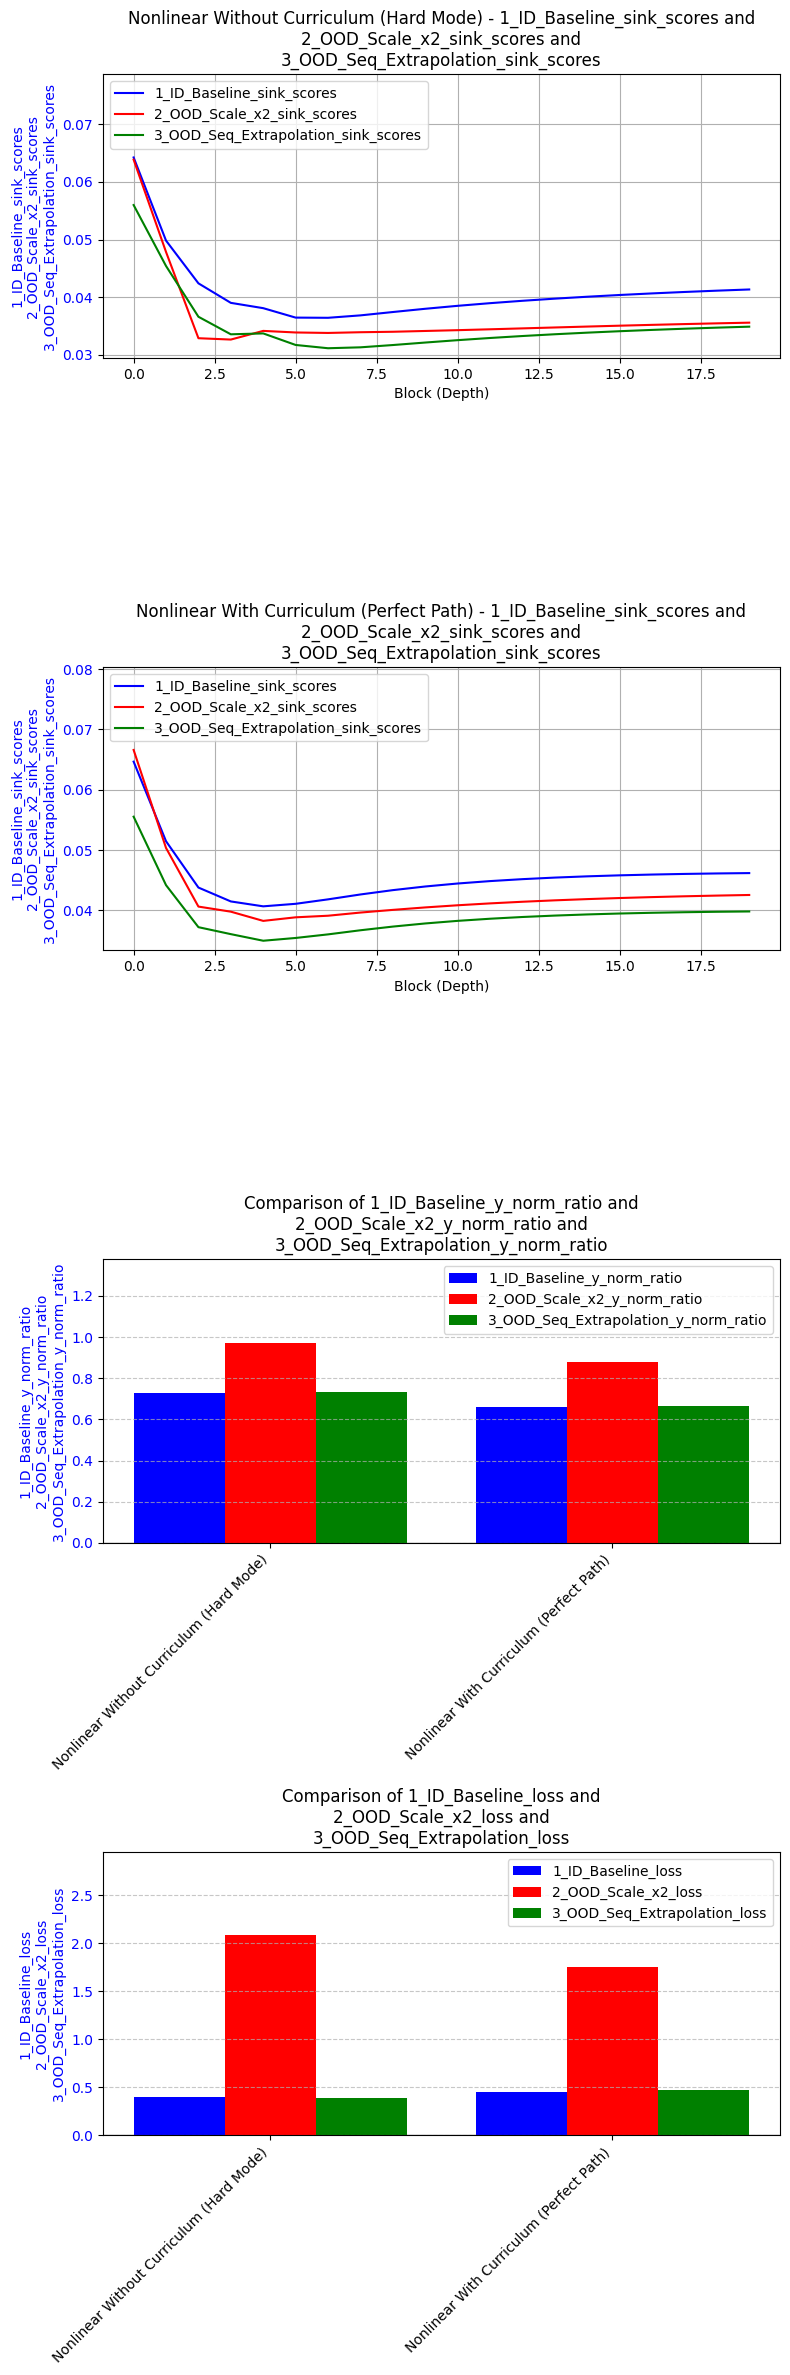

In [61]:
test_table = ExperimentTable(params_groups=param_groups, manual=manual_config)
test_table.run(result_lists=results_lists, modes=['evaluate'], eval_configs=eval_configs)
test_table.plot(compare_experiments=False, subplot_shape=(-1,1),suptitle='')

# Lorenz Attractor 实验

In [210]:
create_lorenz_pool(pool_size=800000, traj_len=1000, dt=0.01, sigma=10.0, beta=8/3, rho=28.0, save_path='auto')

检测到已有数据文件，正在读取并进行增量拼接...
增量拼接成功！数据池规模由 111200 条扩大至 911200 条。
数据池已安全写入本地: data/lorenz/length_1000_dt0.01_sigma10.0_beta2.7_rho28.0.pth


## 实验

In [ ]:
# %% [markdown]
# ## Lorenz Attractor Looped Transformer 实验
# %% [markdown]
# ### 任务配置

# %%
import torch
import torch.nn.functional as F
# 确保在运行此脚本前，你已经在此环境中运行或 import 了你的 ExperimentTable, default_setup 等模块

# 提示：在这里填入你刚刚定量生成的离线池本地路径
MY_LORENZ_POOL_PATH = 'data/lorenz/length_1000_dt0.01_sigma10.0_beta2.7_rho28.0.pth'

manual_config = dict(
    # 1. 【核心修改】任务基础配置切换为 Lorenz
    data_type='lorenz',
    d_x=3,                       # 洛伦兹状态空间的绝对物理维度 (X, Y, Z)
    d_y=3,                       # 预测目标同样是完整的三维下一时刻状态
    max_seq_len=500,
    seq_len=300,                  # 上下文包含 150 个 (x, y) 对
    batch_size=64,

    # 模型架构 (完全对齐论文与你的默认优秀设定)
    num_blocks=20,
    num_eff=15,
    d_model=256,
    num_heads=8,
    pe_type=['learned_ape'],     # 使用你在线性任务中表现优异的 Learned APE

    # 核心物理机制配置
    x_init='zero',               # 绝对零起点，迫使模型完全依赖 Prompt 的 ICL 驱动
    init_std='auto',             # 方差自适应 (1/sqrt(256))
    residual_gate=(1, 1),        # 标准残差注入
    residual_gate_type='fixed',

    # 【核心修改】接入洛伦兹数据代入的特定物理参数
    lorenz_kwargs=dict(dt=0.01, burn_in=500),
    load_lorenz_from=MY_LORENZ_POOL_PATH,   # 载入你的高密度离线系综池

    # 优化器剥离外挂
    optimizer_type='adam', 
    lr=1e-4,
    layer_weight_decay=1.0,      # 关闭层级惩罚
    seq_weight_decay=1.0,        # 关闭时间步惩罚
    scheduler_type=None,         # 恒定学习率

    # 运行控制
    epochs=30,
    steps_per_epoch=200,
    print_every=5,

    scheduled_training=True,      # 开启层数 b 的 Kick-start 渐进
    save_path='auto',
    load_path='auto'
)

param_groups = [
    {
        'experiment_name': 'Lorenz Without Curriculum (Hard Mode)',
        'curriculum': {}          # 空字典关闭课程学习，一上来就啃 80 步长序列
    },
    {
        'experiment_name': 'Lorenz With Curriculum (Perfect Path)',
        # 💡 【理论调整点】：删除了带有隐患的 'd_x' 渐变，仅对时序步长进行课程演进
        'curriculum': {
            'seq_len': 20,        # 课程从极短的 20 步（10对点）开始，降低初始积分关联难度
            'duration_ratio': 0.8 # 前 30 个 epoch 随着线性进度逐步拉长到 300 步
        }
    }
]

# 用于最终多场景 OOD 综合性能度量的指标看板
results_lists = [
    (['1_ID_Baseline_sink_scores','2_OOD_Param_Shift_sink_scores', '3_OOD_Seq_Extrapolation_sink_scores'], 'block'),
    (['1_ID_Baseline_y_norm_ratio', '2_OOD_Param_Shift_y_norm_ratio', '3_OOD_Seq_Extrapolation_y_norm_ratio'], 'experiment'),
    (['1_ID_Baseline_loss', '2_OOD_Param_Shift_loss', '3_OOD_Seq_Extrapolation_loss'], 'experiment')
]

# 针对混沌混沌特征量身定制的 OOD 测试集
eval_configs = [
    # 1. 分布内基准 (使用在线即时生成，检验模型对流形任一位置的单步预测)
    {'eval_name': '1_ID_Baseline', 'ood_kwargs': {}}, 
    
    # 2. 物理流形参数偏移 (Parameter Shift)
    # 将瑞利数 rho 向上偏移 5.0（变成 33.0），测试网络是否掌握了隐式微分算子，还是只会背吸引子几何外形
    {'eval_name': '2_OOD_Param_Shift', 'ood_kwargs': {'rho_shift': 5.0}}, 
    
    # 3. 混沌时序长度外推 (Sequence Extrapolation)
    # 将序列长度外推 20%，跨入更长历史的确定性窗口，测试注意力机制的泛化边界
    {'eval_name': '3_OOD_Seq_Extrapolation', 'ood_kwargs': {'seq_len_scale': 1.2}} 
]

# %% [markdown]
# ### 训练环节


In [ ]:

# %%
lorenz_table = ExperimentTable(params_groups=param_groups, manual=manual_config)
# 启动多实验并行，开启你的系综平均训练
lorenz_table.run(result_lists=[(['loss_history'], 'epoch'), (['y_norm_ratio_history'], 'epoch')])

# 可视化两个实验在训练过程中的 Loss 收敛轨迹
lorenz_table.plot(subplot_shape=(-1, 1), 
                  suptitle='Lorenz Attractor Dynamic Curriculum Learning Comparison')

# %% [markdown]
# ### 评估环节 (自动化零线对齐多指标可视化)


In [ ]:

# %%
test_table = ExperimentTable(params_groups=param_groups, manual=manual_config)
# 开启评估模式。注意：评估时代码会自动切换为直接在线生成，保证测试样本的“纯净度”
test_table.run(result_lists=results_lists, modes=['evaluate'], eval_configs=eval_configs, parallel_workers=2)

# 打印最终结果，查看在物理参数偏移与长序列外推下，有无课程学习对 Attention Sink 汇聚率的长期负荷影响
test_table.plot(compare_experiments=False, subplot_shape=(-1,1), suptitle='OOD Evaluation Metrics on Chaotic Systems')